# Khám phá & tiền xử lý (EDA) — Logic_Based_Educational_Queries

**Notebook:** `notebooks/eda_and_Preprocessing.ipynb`  
**Dữ liệu:** `data/raw/Logic_Based_Educational_Queries.json` (đường dẫn tương đối gốc project — ô code tự suy `PROJECT_ROOT`).  

**Kaggle / Colab:** cần **full repo** (có `src/services` + `data/`). Gán `LOGIC_PROJECT_ROOT` trỏ tới  
- thư mục **`Logic_Based_Educational_Queries_Project`**, *hoặc*  
- thư mục **cha** (vd. clone `Exact_2026_...` — code sẽ thử thêm `.../Logic_Based_Educational_Queries_Project`).  
Có thể `%cd` vào một trong hai trước khi chạy ô code.


In [1]:
from __future__ import annotations

import json
import re
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# --- Project root (Logic_Based_Educational_Queries_Project) ---
_cwd = Path.cwd().resolve()
PROJECT_ROOT = None
for anchor in (_cwd, *_cwd.parents):
    if (anchor / "src" / "services").is_dir() and (anchor / "data").is_dir():
        PROJECT_ROOT = anchor
        break
if PROJECT_ROOT is None:
    raise RuntimeError("Không tìm thấy project root (cần thư mục có data/ và src/services/).")

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Logic_Based_Educational_Queries.json"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
OUT_DIR = PROJECT_ROOT / "data" / "interim" / "eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

BTC = {
    "n_records": 411,
    "n_questions": 808,
    "q_per_record": 1.97,
    "nl_per_record": 10.8,
    "mcq": 358,
    "yn_uncertain": 216,
    "open": 234,
    "fol_pct": 99,
}

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"Data: {DATA_PATH}")
print(f"Exists: {DATA_PATH.exists()}")


PROJECT_ROOT: E:\exact_2026\Exact_2026_Laplace-s_Red_Devils\Logic_Based_Educational_Queries_Project
Data: E:\exact_2026\Exact_2026_Laplace-s_Red_Devils\Logic_Based_Educational_Queries_Project\data\raw\Logic_Based_Educational_Queries.json
Exists: True


In [2]:
import os
import sys
from pathlib import Path

_RAW = Path("data/raw/Logic_Based_Educational_Queries.json")


def _project_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in (cwd, cwd.parent):
        if (p / _RAW).is_file():
            return p
    v = os.environ.get("LOGIC_PROJECT_ROOT", "").strip()
    if v:
        r = Path(v).expanduser().resolve()
        for p in (r, r / "Logic_Based_Educational_Queries_Project"):
            if (p / _RAW).is_file():
                return p
    raise RuntimeError("Không thấy data/raw JSON — %cd project/notebooks hoặc LOGIC_PROJECT_ROOT")


PROJECT_ROOT = _project_root()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

DATA_PATH = (PROJECT_ROOT / _RAW).resolve()
FIG_DIR, OUT_DIR = PROJECT_ROOT / "reports/figures", PROJECT_ROOT / "data/interim/eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(PROJECT_ROOT, DATA_PATH.exists())


E:\exact_2026\Exact_2026_Laplace-s_Red_Devils\Logic_Based_Educational_Queries_Project True


In [3]:
# --- Helpers: biểu đồ cho thống kê % / phân bố ---
PALETTE = sns.color_palette("muted")


def plot_pct_bars(metrics: dict[str, float], title: str, filename: str, figsize=None) -> None:
    """Bar chart ngang: mỗi metric là % (0–100)."""
    if figsize is None:
        figsize = (9, max(3, len(metrics) * 0.55))
    labels = list(metrics.keys())
    values = list(metrics.values())
    # barh: đảo để mục đầu dict nằm trên cùng biểu đồ
    labels = labels[::-1]
    values = values[::-1]
    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.barh(labels, values, color=PALETTE[0], edgecolor="white")
    ax.set_xlim(0, min(105, max(values) * 1.25 + 5 if values else 100))
    ax.set_xlabel("%")
    ax.set_title(title)
    for bar, v in zip(bars, values):
        ax.text(v + 0.8, bar.get_y() + bar.get_height() / 2, f"{v:.1f}%", va="center", fontsize=10)
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=120, bbox_inches="tight")
    plt.show()


def plot_count_dist(
    series: pd.Series,
    title: str,
    filename: str,
    top_n: int | None = 15,
    horizontal: bool = True,
    *,
    preaggregated: bool = False,
) -> None:
    """Phân bố đếm. preaggregated=True: index=nhãn, value=đã đếm sẵn (không gọi value_counts)."""
    if preaggregated:
        vc = series.sort_values(ascending=True)
        if top_n:
            vc = vc.tail(top_n)
        total = float(vc.sum()) or 1.0
    else:
        vc = series.value_counts()
        if top_n:
            vc = vc.head(top_n)
        total = len(series)
    fig, ax = plt.subplots(figsize=(10, max(4, len(vc) * 0.35)))
    plot_fn = vc.plot.barh if horizontal else vc.plot.bar
    plot_fn(ax=ax, color=PALETTE[1], edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Số lượng")
    for i, (idx, v) in enumerate(vc.items()):
        pct = 100 * v / total
        if horizontal:
            ax.text(v + max(vc) * 0.01, i, f" {v} ({pct:.1f}%)", va="center", fontsize=9)
        else:
            ax.text(i, v, f"{v}\n({pct:.1f}%)", ha="center", fontsize=8)
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=120, bbox_inches="tight")
    plt.show()


def plot_binary_pie(yes_pct: float, title: str, filename: str, yes_label: str = "Có", no_label: str = "Không") -> None:
    """Pie chart cho 1 tỷ lệ % (có/không)."""
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.pie(
        [yes_pct, 100 - yes_pct],
        labels=[f"{yes_label}\n{yes_pct:.1f}%", f"{no_label}\n{100-yes_pct:.1f}%"],
        autopct="",
        colors=[PALETTE[2], "#E0E0E0"],
        startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 1.2},
    )
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=120, bbox_inches="tight")
    plt.show()


def plot_heatmap_ct(ct: pd.DataFrame, title: str, filename: str) -> None:
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", ax=ax, linewidths=0.5)
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=120, bbox_inches="tight")
    plt.show()


## 1. Load & flatten


In [4]:
with open(DATA_PATH, encoding="utf-8") as f:
    records = json.load(f)

print(f"Số record: {len(records)}  [BTC: {BTC['n_records']}]")

missing_fol_ids = [rid for rid, r in enumerate(records) if "premises-FOL" not in r]
if missing_fol_ids:
    print(f"⚠ {len(missing_fol_ids)} mẫu thiếu premises-FOL (chỉ có NL): {missing_fol_ids}")


def get_fol(rec: dict) -> list[str]:
    """Một số record không có FOL — trả list rỗng thay vì KeyError."""
    return rec.get("premises-FOL", [])


def normalize_idx(idx: list, n_questions: int) -> list[list]:
    """Chuẩn hóa idx: [[1],[2,3]] hoặc flat [1,2,3] khi chỉ 1 câu (record 132, 133)."""
    if not idx:
        return [[] for _ in range(n_questions)]
    if all(isinstance(x, int) for x in idx):
        return [list(idx)] if n_questions == 1 else [list(idx)] * n_questions
    return idx


def flatten_records(recs: list[dict]) -> pd.DataFrame:
    rows = []
    for rid, rec in enumerate(recs):
        n_prem = len(rec["premises-NL"])
        fol_list = get_fol(rec)
        n_fol = len(fol_list)
        idx_lists = normalize_idx(rec["idx"], len(rec["questions"]))
        for qi, (q, a, exp, idx_used) in enumerate(
            zip(rec["questions"], rec["answers"], rec["explanation"], idx_lists)
        ):
            rows.append(
                {
                    "record_id": rid,
                    "q_idx": qi,
                    "n_premises_nl": n_prem,
                    "n_premises_fol": n_fol,
                    "n_premises_used": len(idx_used),
                    "premise_use_ratio": len(idx_used) / n_prem if n_prem else np.nan,
                    "idx_used": idx_used,
                    "question": q,
                    "answer": a,
                    "explanation": exp,
                    "premises_nl": rec["premises-NL"],
                    "premises_fol": fol_list,
                }
            )
    return pd.DataFrame(rows)


df_q = flatten_records(records)
print(f"Tổng câu flatten: {len(df_q)}  [BTC: {BTC['n_questions']}]")


def row_to_record_dict(row) -> dict:
    """1 câu trong df_q → dict cùng thứ tự / tên field như JSON gốc."""
    return {
        "idx": [list(row["idx_used"])],
        "premises-FOL": list(row["premises_fol"]),
        "premises-NL": list(row["premises_nl"]),
        "questions": [row["question"]],
        "answers": [row["answer"]],
        "explanation": [row["explanation"]],
    }


df_q.head(2)


Số record: 411  [BTC: 411]
Tổng câu flatten: 808  [BTC: 808]


,record_id,q_idx,n_premises_nl,n_premises_fol,n_premises_used,premise_use_ratio,idx_used,question,answer,explanation,premises_nl,premises_fol
0,0,0,14,14,1,0.071429,[1],Which conclusion follows with the fewest premi...,A,Premise 1 states that if a Python project is w...,"[If a Python code is well-tested, then the pro...","[∀x (WT(x) → O(x)), ∀x (¬PEP8(x) → ¬WT(x)), ∀x..."
1,0,1,14,14,2,0.142857,"[7, 10]",Does it follow that if all Python projects are...,Yes,Premise 10 confirms all Python projects are we...,"[If a Python code is well-tested, then the pro...","[∀x (WT(x) → O(x)), ∀x (¬PEP8(x) → ¬WT(x)), ∀x..."


In [5]:
len(df_q['premises_fol'])


808

In [6]:
# Các câu thuộc mẫu không có premises-FOL — in dạng JSON (như file gốc)
for i in range(len(df_q)):
    if len(df_q["premises_fol"].iloc[i]) == 0:
        print(json.dumps(row_to_record_dict(df_q.iloc[i]), ensure_ascii=False, indent=2))
        print("-" * 60)


In [7]:
df_rec = pd.DataFrame(
    {
        "record_id": range(len(records)),
        "questions_per_record": [len(r["questions"]) for r in records],
        "n_premises_nl": [len(r["premises-NL"]) for r in records],
        "n_premises_fol": [len(get_fol(r)) for r in records],
        "nl_fol_match": [
            len(r["premises-NL"]) == len(get_fol(r)) for r in records
        ],
        "has_fol": [len(get_fol(r)) > 0 for r in records],
    }
)
df_rec.head()


,record_id,questions_per_record,n_premises_nl,n_premises_fol,nl_fol_match,has_fol
0,0,2,14,14,True,True
1,1,2,11,11,True,True
2,2,2,11,11,True,True
3,3,2,7,7,True,True
4,4,2,8,8,True,True


## 2. Số câu hỏi / 1 mẫu


In [8]:
qpc = df_rec["questions_per_record"]

print("=== questions_per_record ===")
print(qpc.describe())
print(f"Mode: {qpc.mode().iloc[0]} câu/mẫu (xuất hiện {qpc.value_counts().iloc[0]} lần)")

total_questions = int(qpc.sum())
print(f"Tổng câu (sum): {total_questions}  |  BTC: {BTC['n_questions']}  |  Khớp: {total_questions == BTC['n_questions']}")

outlier_rid = int(qpc.idxmax())
print(f"Outlier: record_id={outlier_rid}, questions={qpc.max()}")

print("\n=== Histogram ===")
vc = qpc.value_counts().sort_index()
for k, v in vc.items():
    print(f"  {k} câu/mẫu: {v:3d} mẫu ({100*v/len(qpc):5.1f}%)")

p50 = qpc.median()
pct_1 = 100 * (qpc == 1).mean()
pct_2 = 100 * (qpc == 2).mean()
print(
    f"\nTóm tắt: Một mẫu trung bình có {qpc.mean():.2f} câu (P50={p50:.0f}, max={qpc.max()}). "
    f"{pct_1:.1f}% mẫu có 1 câu, {pct_2:.1f}% có 2 câu."
)


=== questions_per_record ===
count    411.000000
mean       1.965937
std        0.181613
min        1.000000
25%        2.000000
50%        2.000000
75%        2.000000
max        2.000000
Name: questions_per_record, dtype: float64
Mode: 2 câu/mẫu (xuất hiện 397 lần)
Tổng câu (sum): 808  |  BTC: 808  |  Khớp: True
Outlier: record_id=0, questions=2

=== Histogram ===
  1 câu/mẫu:  14 mẫu (  3.4%)
  2 câu/mẫu: 397 mẫu ( 96.6%)

Tóm tắt: Một mẫu trung bình có 1.97 câu (P50=2, max=2). 3.4% mẫu có 1 câu, 96.6% có 2 câu.


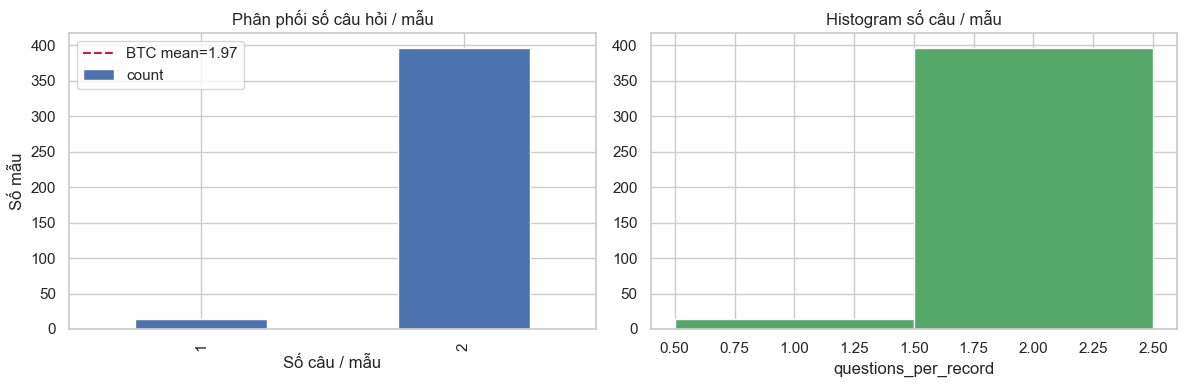

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

vc.plot(kind="bar", ax=axes[0], color="#4C72B0", edgecolor="white")
axes[0].set_title("Phân phối số câu hỏi / mẫu")
axes[0].set_xlabel("Số câu / mẫu")
axes[0].set_ylabel("Số mẫu")
axes[0].axvline(BTC["q_per_record"], color="crimson", ls="--", label=f"BTC mean={BTC['q_per_record']}")
axes[0].legend()

axes[1].hist(qpc, bins=range(1, int(qpc.max()) + 2), color="#55A868", edgecolor="white", align="left")
axes[1].set_title("Histogram số câu / mẫu")
axes[1].set_xlabel("questions_per_record")

plt.tight_layout()
plt.savefig(FIG_DIR / "Q_questions_per_record.png", dpi=120, bbox_inches="tight")
plt.show()


In [10]:
# In các mẫu chỉ có 1 câu hỏi
for i in range(len(df_rec)):
    if df_rec['questions_per_record'].iloc[i] == 1:
        # in full record dạng JSON
        print(f"Mẫu {i} có 1 câu hỏi")
        sample = records[i]
        print(json.dumps(sample, ensure_ascii=False, indent=2))
        print("-" * 60)
        print("\n\n")


Mẫu 28 có 1 câu hỏi
{
  "idx": [
    [
      1,
      2,
      3,
      4,
      5,
      9,
      11,
      13,
      16
    ]
  ],
  "premises-FOL": [
    "ForAll(a, (training(a) ∧ simulations(a)) → clearance(a))",
    "ForAll(a, (clearance(a) ∧ safety_audit(vehicle(a))) → approved(a))",
    "ForAll(a, (approved(a) ∧ trajectory(a)) → departs(a))",
    "ForAll(a, (departs(a) ∧ safe_radiation(Mars)) → landing(a))",
    "ForAll(a, (landing(a) ∧ rover(a)) → samples(a))",
    "ForAll(a, (samples(a) ∧ equipment(a)) → breakthrough(a))",
    "training(Luna) ∨ withdraw(Luna)",
    "¬withdraw(Luna)",
    "simulations(Luna)",
    "safety_audit(vehicle(Luna))",
    "trajectory(Luna)",
    "safe_radiation(Mars)",
    "rover(Luna)",
    "equipment(Luna)",
    "lose_contact(control) → ¬trajectory(Luna)",
    "¬lose_contact(control)",
    "malfunction(rover(Luna)) → ¬samples(Luna)",
    "¬malfunction(rover(Luna))",
    "exceed_radiation(Mars) → ¬landing(Luna)",
    "¬exceed_radiation(Mars)",
    "fa

In [11]:
print("=== mean premise dùng / câu theo số câu trong mẫu ===")
q7 = (
    df_q.groupby(df_rec.loc[df_q["record_id"], "questions_per_record"].values)
    ["n_premises_used"]
    .agg(["mean", "median", "count"])
    .rename_axis("questions_per_record")
)
print(q7)


=== mean premise dùng / câu theo số câu trong mẫu ===
                          mean  median  count
questions_per_record                         
1                     6.357143     4.5     14
2                     2.578086     2.0    794


## 3. Schema & integrity


In [12]:
align_errors = []
empty_errors = []
idx_errors = []

for rid, rec in enumerate(records):
    nq = len(rec["questions"])
    na, ne = len(rec["answers"]), len(rec["explanation"])
    ni = len(normalize_idx(rec["idx"], nq))
    if not (nq == na == ne == ni):
        align_errors.append((rid, nq, na, ne, ni))
    if nq == 0 or len(rec["premises-NL"]) == 0:
        empty_errors.append(rid)
    n_prem = len(rec["premises-NL"])
    for qi, idx_list in enumerate(normalize_idx(rec["idx"], nq)):
        for ix in idx_list:
            if ix < 1 or ix > n_prem:
                idx_errors.append((rid, qi, ix, n_prem))

nl_fol_mismatch = [
    rid for rid, r in enumerate(records)
    if get_fol(r) and len(r["premises-NL"]) != len(get_fol(r))
]
missing_fol_only = missing_fol_ids  # đã in ở cell load

print(f"Lệch len(q,a,exp,idx): {len(align_errors)} record")
print(f"NL≠FOL count: {len(nl_fol_mismatch)} record (có FOL nhưng lệch độ dài)")
print(f"Thiếu hẳn premises-FOL: {len(missing_fol_only)} record {missing_fol_only}")
print(f"List rỗng: {len(empty_errors)} record")
print(f"idx ngoài range: {len(idx_errors)} lỗi")
if idx_errors[:3]:
    print("  Ví dụ:", idx_errors[:3])


def record_to_json_dict(rec: dict) -> dict:
    """Record → JSON đúng format gốc (premises-FOL nếu có)."""
    out = {
        "idx": rec["idx"],
        "premises-NL": rec["premises-NL"],
        "questions": rec["questions"],
        "answers": rec["answers"],
        "explanation": rec["explanation"],
    }
    fol = get_fol(rec)
    if fol:
        out["premises-FOL"] = fol
    return out


SEP_REC = "=" * 72
print(f"\n{SEP_REC}")
print(f"Mẫu NL ≠ FOL — in full JSON ({len(nl_fol_mismatch)} record)")
print(SEP_REC)
for rid in nl_fol_mismatch:
    rec = records[rid]
    print(f"\n[record_id={rid}] NL={len(rec['premises-NL'])} | FOL={len(get_fol(rec))}")
    print(json.dumps(record_to_json_dict(rec), ensure_ascii=False, indent=2))


Lệch len(q,a,exp,idx): 0 record
NL≠FOL count: 11 record (có FOL nhưng lệch độ dài)
Thiếu hẳn premises-FOL: 0 record []
List rỗng: 0 record
idx ngoài range: 0 lỗi

Mẫu NL ≠ FOL — in full JSON (11 record)

[record_id=34] NL=27 | FOL=25
{
  "idx": [
    [
      1,
      2,
      3,
      4,
      6,
      8,
      12,
      13,
      14,
      20,
      22,
      23,
      24,
      26
    ]
  ],
  "premises-NL": [
    "Students are allowed to change majors if their cumulative GPA is 7.0 or higher.",
    "Students must complete at least 2 semesters in their current major before changing.",
    "Accumulated credits must be at least 50% of the total credits of the current program.",
    "The new major must have a professional similarity of 60% or higher, as determined by the professional council.",
    "If students have taken major-specific courses, these courses must be assessed for knowledge equivalence with the new major.",
    "The major change must be approved by the academic council a

## 4. Loại câu hỏi


=== Loại câu (loại trừ lẫn nhau) ===
q_type
mcq     359
open    233
yn      216

  [BTC: MCQ=358, Y/N=216, Open=234]


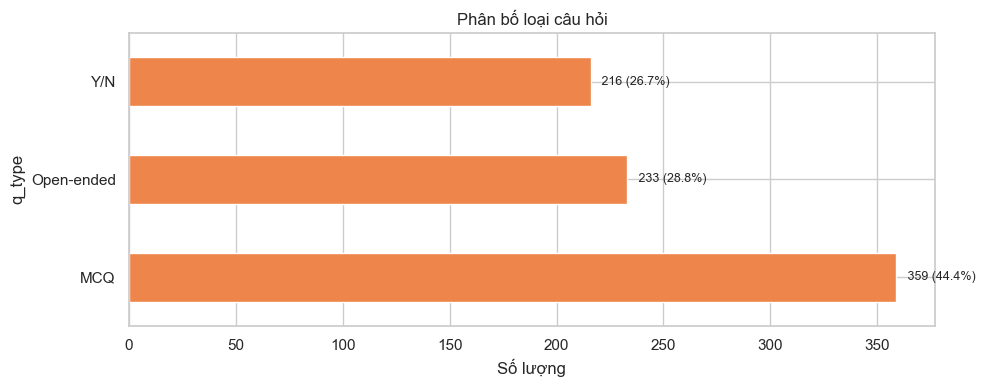

In [13]:
MCQ_PAT = re.compile(
    r"\nA\.|\nB\.|strongest conclusion|fewest premises|Which conclusion|"
    r"which of the following|which is the strongest|which of these conclusions",
    re.I,
)
YN_PAT = re.compile(
    r"Does it follow|according to the premises|is the following statement true|"
    r"is the following true\?|Must .+ follow from|Can .+ be inferred|"
    r"Does .+ follow that|Is it true that",
    re.I,
)


def classify_q_type(text: str) -> str:
    """Phân loại loại trừ lẫn nhau — khớp gần BTC (358 / 216 / 234)."""
    if MCQ_PAT.search(text):
        return "mcq"
    if YN_PAT.search(text):
        return "yn"
    return "open"


df_q["q_type"] = df_q["question"].apply(classify_q_type)
df_q["is_mcq"] = df_q["q_type"] == "mcq"
df_q["is_yn"] = df_q["q_type"] == "yn"
df_q["is_open"] = df_q["q_type"] == "open"

print("=== Loại câu (loại trừ lẫn nhau) ===")
print(df_q["q_type"].value_counts().to_string())
print(f"\n  [BTC: MCQ={BTC['mcq']}, Y/N={BTC['yn_uncertain']}, Open={BTC['open']}]")
q_type_labels = df_q["q_type"].map({"mcq": "MCQ", "yn": "Y/N", "open": "Open-ended"})
plot_count_dist(q_type_labels, "Phân bố loại câu hỏi", "D_question_types.png", top_n=None)


### Phân phối độ dài token theo loại câu (Qwen2.5-7B)

Ngay sau thống kê số câu mỗi loại: đếm **tổng token** trên chuỗi thô ghép premises (NL/FOL) + question + answer + explanation (MCQ / logic) — **không** dùng template chat FOL SFT. Mục này giúp hình dung độ dài ngữ cảnh câu hỏi logic.

**Pipeline FOL SFT** (system/user/assistant đúng `fol_dataset`): xem mục markdown **«Phân phối độ dài token — pipeline FOL SFT»** ngay sau ô biểu đồ bên dưới.


c:\Users\ASUS\anaconda3\envs\DS310_env_3_10\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Đang tải tokenizer Qwen/Qwen2.5-7B-Instruct ...


OK.

=== Phân phối token (full context / câu) ===

--- Token / câu — Tất cả (n=808) ---
  mean=474  min=115  max=1693
  P50=450
  P90=760
  P95=867
  % > 2048: 0.0%
  % > 4096: 0.0%
  % > 8192: 0.0%

--- Token / câu — MCQ (n=359) ---
  mean=493  min=175  max=1286
  P50=471
  P90=756
  P95=852
  % > 2048: 0.0%
  % > 4096: 0.0%
  % > 8192: 0.0%



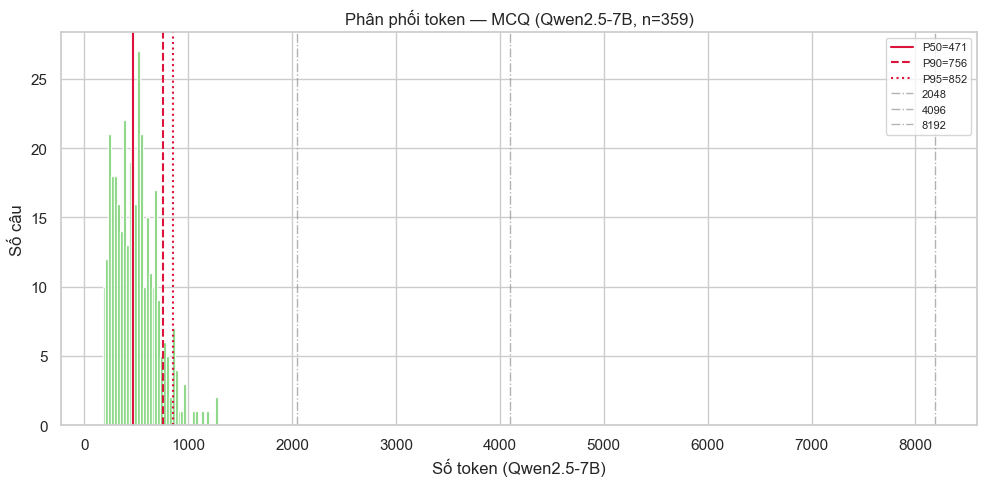

--- Token / câu — Y/N (n=216) ---
  mean=427  min=115  max=1209
  P50=436
  P90=646
  P95=753
  % > 2048: 0.0%
  % > 4096: 0.0%
  % > 8192: 0.0%



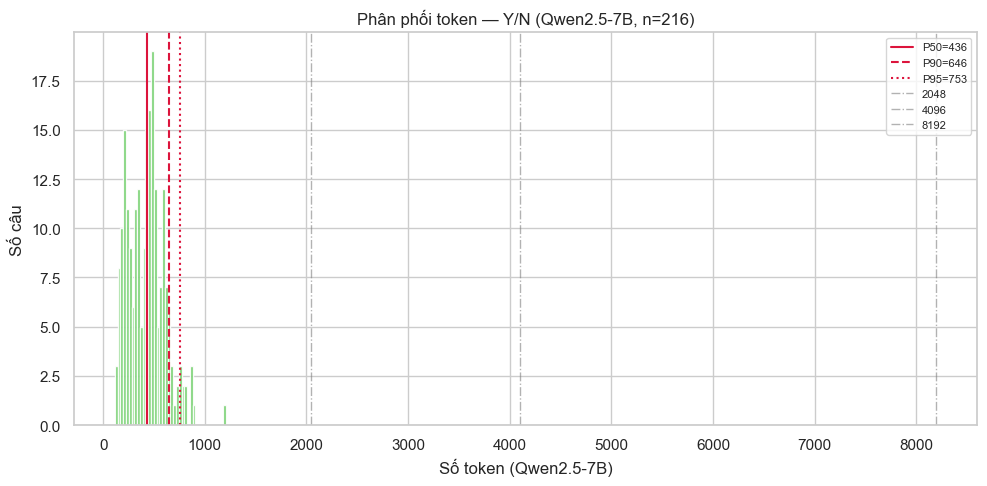

--- Token / câu — Open-ended (n=233) ---
  mean=490  min=158  max=1693
  P50=433
  P90=852
  P95=944
  % > 2048: 0.0%
  % > 4096: 0.0%
  % > 8192: 0.0%



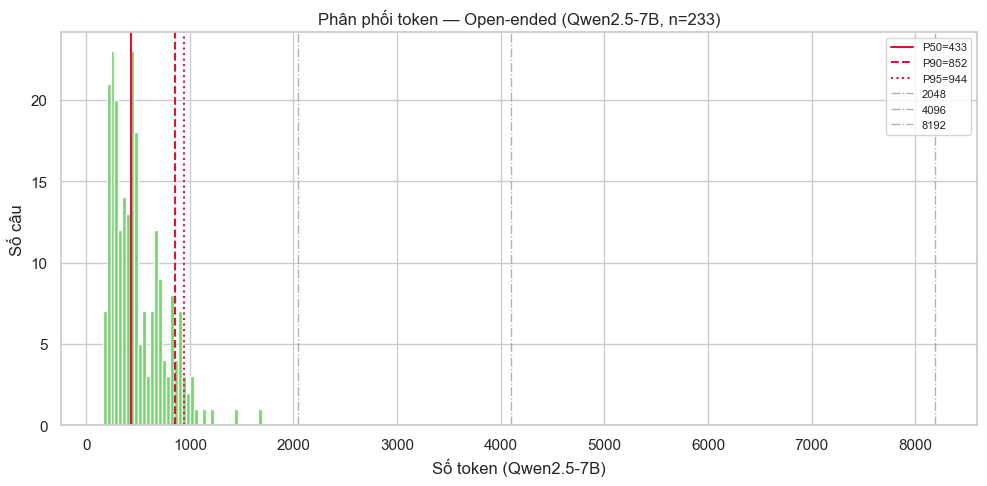

Gợi ý max_seq_length (P95 toàn tập ≈ 867): 1024 hoặc 2048


In [14]:
from transformers import AutoTokenizer

print("Đang tải tokenizer Qwen/Qwen2.5-7B-Instruct ...")
_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-7B-Instruct", trust_remote_code=True)
print("OK.\n")


def _build_finetune_text(row) -> str:
    parts = []
    if row["premises_fol"]:
        parts.append("Premises (FOL):\n" + "\n".join(str(x) for x in row["premises_fol"]))
    if row["premises_nl"]:
        parts.append("Premises (NL):\n" + "\n".join(str(x) for x in row["premises_nl"]))
    parts.append("Question:\n" + str(row["question"]))
    if row.get("answer"):
        parts.append("Answer:\n" + str(row["answer"]))
    if row.get("explanation"):
        parts.append("Explanation:\n" + str(row["explanation"]))
    return "\n\n".join(parts)


def _count_tokens(text: str) -> int:
    return len(_tokenizer.encode(text, add_special_tokens=False))


if "n_tokens_total" not in df_q.columns:
    df_q["n_tokens_total"] = df_q.apply(
        lambda r: _count_tokens(_build_finetune_text(r)), axis=1
    )

_THRESH = (2048, 4096, 8192)
_BY_TYPE = [
    ("mcq", "MCQ", "D_token_dist_mcq.png"),
    ("yn", "Y/N", "D_token_dist_yn.png"),
    ("open", "Open-ended", "D_token_dist_open.png"),
]


def _print_token_stats(sub: pd.DataFrame, label: str) -> None:
    s = sub["n_tokens_total"]
    print(f"--- Token / câu — {label} (n={len(sub)}) ---")
    print(f"  mean={s.mean():.0f}  min={s.min()}  max={s.max()}")
    for p in (0.5, 0.9, 0.95):
        print(f"  P{int(p*100)}={s.quantile(p):.0f}")
    for t in _THRESH:
        print(f"  % > {t}: {100 * (s > t).mean():.1f}%")
    print()


def _plot_token_hist(sub: pd.DataFrame, title: str, filename: str) -> None:
    s = sub["n_tokens_total"]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(s, bins=40, color=PALETTE[2], edgecolor="white", alpha=0.9)
    for p, ls in [(0.5, "-"), (0.9, "--"), (0.95, ":")]:
        v = s.quantile(p)
        ax.axvline(v, color="crimson", linestyle=ls, lw=1.5, label=f"P{int(p*100)}={v:.0f}")
    for t in _THRESH:
        ax.axvline(t, color="gray", linestyle="-.", lw=1, alpha=0.6, label=str(t))
    ax.set_xlabel("Số token (Qwen2.5-7B)")
    ax.set_ylabel("Số câu")
    ax.set_title(title)
    ax.legend(fontsize=8, loc="upper right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=120, bbox_inches="tight")
    plt.show()


print("=== Phân phối token (full context / câu) ===\n")
_print_token_stats(df_q, "Tất cả")
for qkey, qlabel, fname in _BY_TYPE:
    sub = df_q[df_q["q_type"] == qkey]
    _print_token_stats(sub, qlabel)
    _plot_token_hist(
        sub,
        f"Phân phối token — {qlabel} (Qwen2.5-7B, n={len(sub)})",
        fname,
    )

p95 = df_q["n_tokens_total"].quantile(0.95)
print(f"Gợi ý max_seq_length (P95 toàn tập ≈ {p95:.0f}): {int(np.ceil(p95 / 256) * 256)} hoặc 2048")



### Phân phối độ dài token — pipeline **FOL SFT** (`text` / `eval_prompt`)

**`max_seq_length` (YAML) giới hạn cả mẫu huấn luyện**: sau `apply_chat_template` gồm **system + user + assistant** — tức **cả instruction few-shot trong `SYSTEM_PROMPT_FOL_SFT`**, khối **`USER_TEMPLATE_FOL_SFT` + premises NL đánh số**, và **JSON gold `premises_fol`** (`src/data/prompts.py` + `build_fol_messages` trong `src/data/fol_dataset.py`, giống 100% lúc nạp vào Trainer).

Ô code bên dưới:

- Đọc `model.name` / `max_seq_length` từ `configs/fol_model.yaml`.
- `build_fol_messages(row)` → assert nội dung system trùng `SYSTEM_PROMPT_FOL_SFT.strip()` (không nhân đôi prompt trong notebook).
- Đếm token: **`text`** (full SFT), **`eval_prompt`** (inference), và thêm **user-only / assistant-only** (chuỗi trong từng role trước template) để bạn thấy phần dữ liệu chiếm bao nhiêu so với khối system cố định.
- Phân vị + histogram; file `FIG_DIR/FOL_token_*.png`.

Khác mục *«Phân phối độ dài token theo loại câu (Qwen2.5-7B)»*: mục đó là **MCQ thô**, không dùng prompt FOL trong `prompts.py`.


Tokenizer: Laplaces-Red-Devils/fol-pretrain-malls-qwen2.5-3  |  max_seq_length (YAML): 2048
processed: E:\exact_2026\Exact_2026_Laplace-s_Red_Devils\Logic_Based_Educational_Queries_Project\data\processed

SYSTEM_PROMPT_FOL_SFT.strip() — token (encode thuần, chưa bọc chat template): 1456 (số token trong `text` sau template thường lớn hơn do special tokens / định dạng chat).
USER_TEMPLATE_FOL_SFT: khối user = template.format(premises_nl=...) (đánh số NL trong `build_fol_user_content`).

train: giữ 630 / 647 (loại 17 dòng không song song NL/FOL)
dev: giữ 79 / 79 (loại 0 dòng không song song NL/FOL)
test: giữ 77 / 81 (loại 4 dòng không song song NL/FOL)

Tổng mẫu FOL (sau lọc): 786
Đã assert: mỗi mẫu dùng system prompt đúng `data/prompts.py` (không nhân bản trong notebook).

=== FOL — full SFT `text` (chat template: system+user+assistant) ===

--- Tất cả split — n_tokens_full (n=786) ---
  mean=1844  min=1535  max=2953
  P50=1804
  P90=2143
  P95=2259
  P99=2504
  % > max_seq_length (2048)

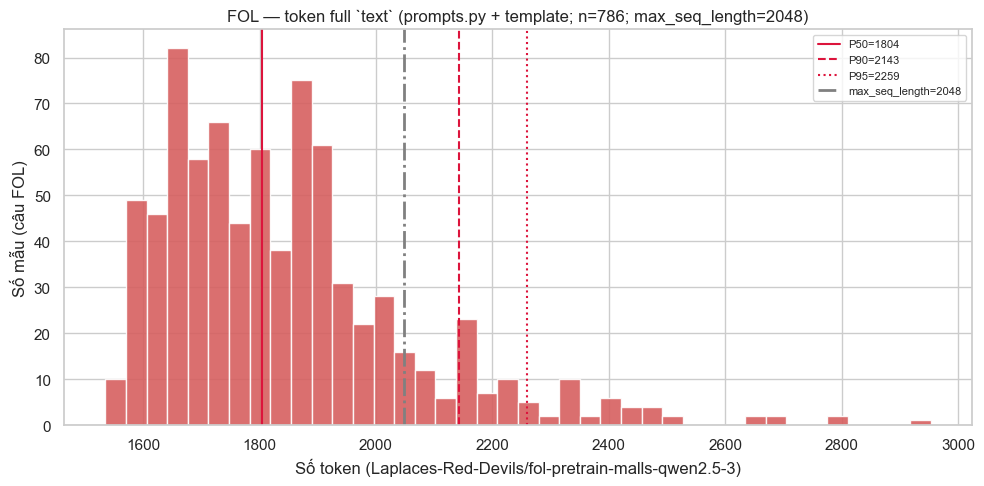

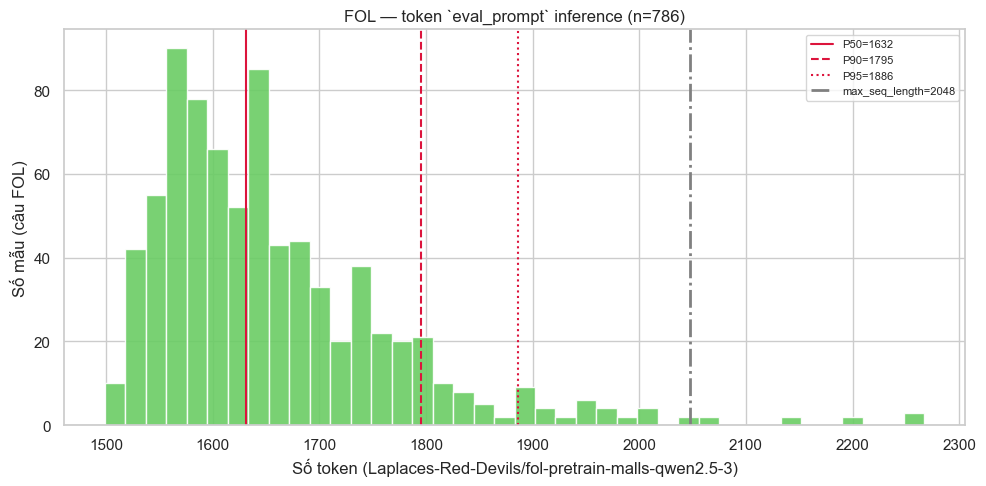

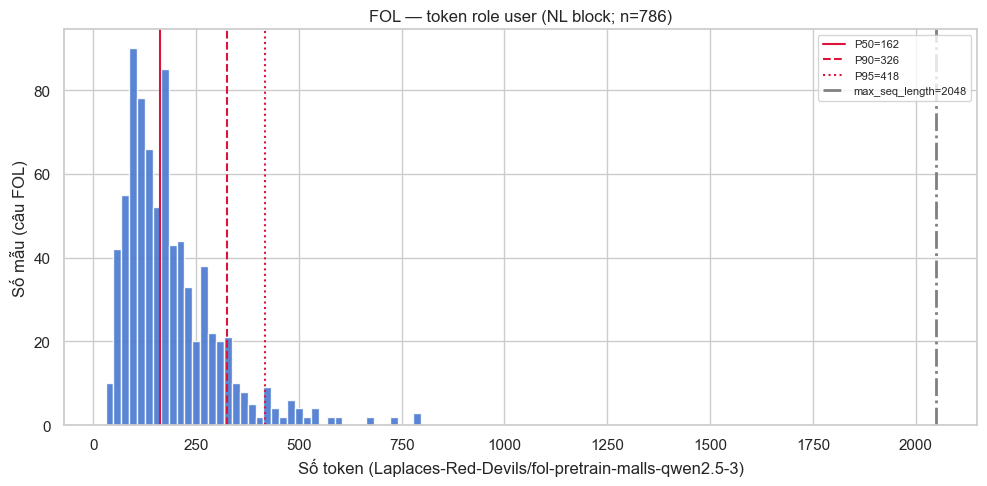

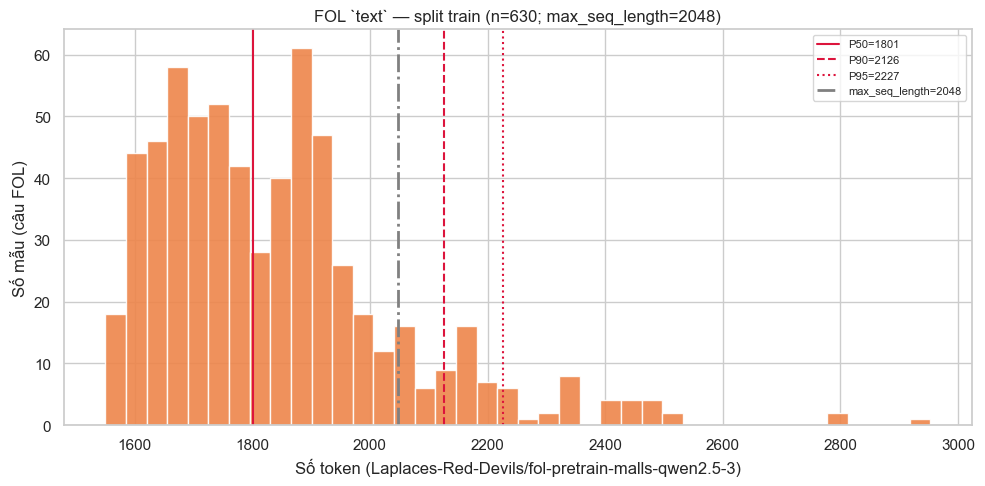

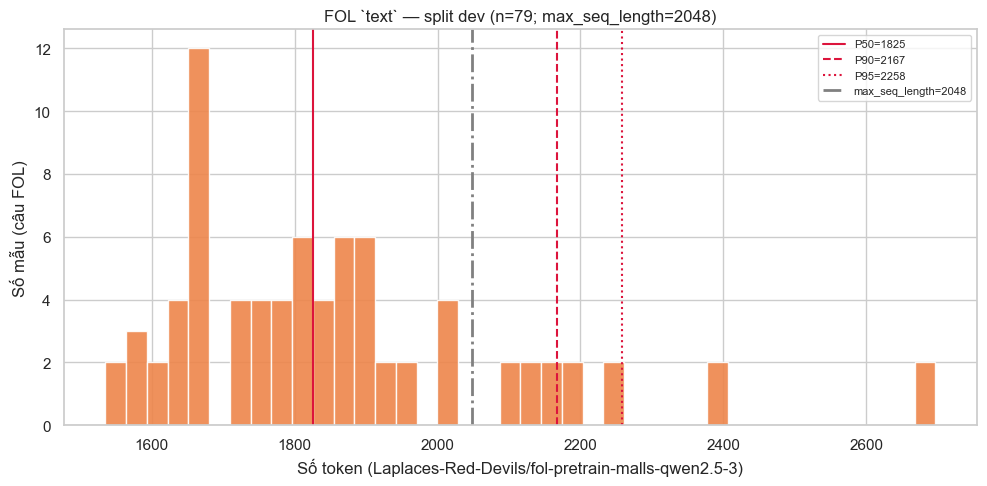

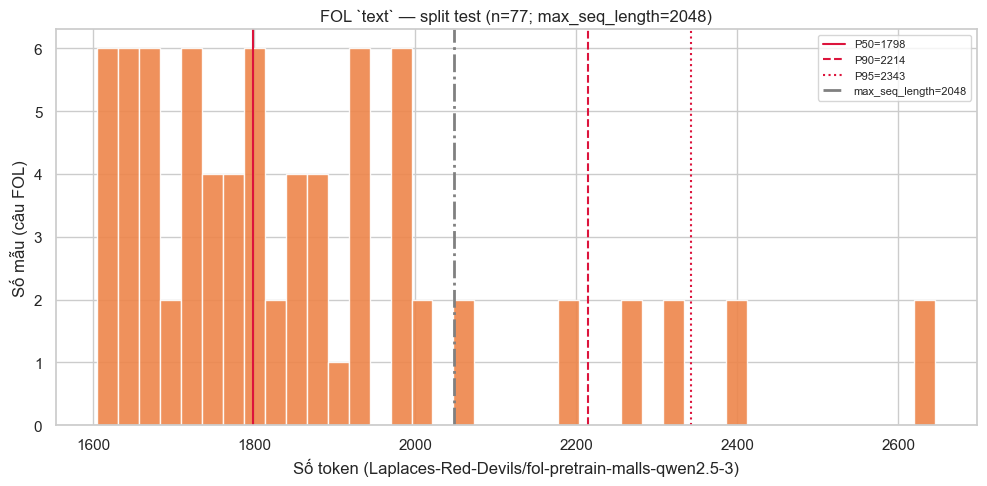

In [15]:
# --- FOL SFT: token length = đúng prompt `src/data/prompts.py` (SYSTEM + USER template + JSON gold)
#     qua `build_fol_messages` trong `fol_dataset.py`, rồi `apply_chat_template` như khi train. ---
from pathlib import Path

try:
    import yaml
except ImportError:
    yaml = None

from transformers import AutoTokenizer

from data.dataset import read_split_csv
from data.fol_dataset import build_fol_messages, filter_rows_parallel_premises
from data.prompts import SYSTEM_PROMPT_FOL_SFT, USER_TEMPLATE_FOL_SFT

_fol_yaml = PROJECT_ROOT / "configs" / "fol_model.yaml"
_fol_model_name = "Qwen/Qwen2.5-3B-Instruct"
_fol_max_seq = 2048
if yaml is not None and _fol_yaml.is_file():
    try:
        raw = yaml.safe_load(_fol_yaml.read_text(encoding="utf-8")) or {}
        m = raw.get("model") or {}
        if isinstance(m, dict) and m.get("name"):
            _fol_model_name = str(m["name"])
        if isinstance(m, dict) and m.get("max_seq_length") is not None:
            _fol_max_seq = int(m["max_seq_length"])
    except Exception as e:
        print("⚠ Không đọc được fol_model.yaml:", e)

_proc = PROJECT_ROOT / "data" / "processed"
_sys_strip = SYSTEM_PROMPT_FOL_SFT.strip()

print(f"Tokenizer: {_fol_model_name}  |  max_seq_length (YAML): {_fol_max_seq}")
print(f"processed: {_proc}\n")

_fol_tok = AutoTokenizer.from_pretrained(_fol_model_name, trust_remote_code=True)
_n_sys_raw = len(_fol_tok.encode(_sys_strip, add_special_tokens=False))
print(
    f"SYSTEM_PROMPT_FOL_SFT.strip() — token (encode thuần, chưa bọc chat template): {_n_sys_raw} "
    "(số token trong `text` sau template thường lớn hơn do special tokens / định dạng chat)."
)
print(
    "USER_TEMPLATE_FOL_SFT: khối user = template.format(premises_nl=...) "
    "(đánh số NL trong `build_fol_user_content`).\n"
)

_rows = []
_prompts_py_verified = False
for split in ("train", "dev", "test"):
    df = read_split_csv(_proc, split)
    df_f, n_drop = filter_rows_parallel_premises(df)
    print(f"{split}: giữ {len(df_f)} / {len(df)} (loại {n_drop} dòng không song song NL/FOL)")
    for row in df_f.to_dict(orient="records"):
        messages = build_fol_messages(row)
        if not _prompts_py_verified:
            assert messages[0]["content"] == _sys_strip, (
                "system phải khớp SYSTEM_PROMPT_FOL_SFT.strip() trong prompts.py"
            )
            assert "### Input" in USER_TEMPLATE_FOL_SFT and "{premises_nl}" in USER_TEMPLATE_FOL_SFT
            _prompts_py_verified = True

        u_txt = messages[1]["content"]
        a_txt = messages[2]["content"]
        n_user = len(_fol_tok.encode(u_txt, add_special_tokens=False))
        n_asst = len(_fol_tok.encode(a_txt, add_special_tokens=False))

        text = _fol_tok.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=False
        )
        eval_prompt = _fol_tok.apply_chat_template(
            messages[:2], tokenize=False, add_generation_prompt=True
        )
        n_full = len(_fol_tok.encode(text, add_special_tokens=False))
        n_pe = len(_fol_tok.encode(eval_prompt, add_special_tokens=False))
        _rows.append(
            {
                "split": split,
                "n_tokens_full": n_full,
                "n_tokens_eval_prompt": n_pe,
                "n_tokens_user_msg": n_user,
                "n_tokens_assistant_msg": n_asst,
            }
        )

df_fol_tok = pd.DataFrame(_rows)
print(f"\nTổng mẫu FOL (sau lọc): {len(df_fol_tok)}")
print(f"Đã assert: mỗi mẫu dùng system prompt đúng `data/prompts.py` (không nhân bản trong notebook).\n")


def _print_fol_token_stats(sub: pd.DataFrame, label: str, col: str) -> None:
    s = sub[col]
    print(f"--- {label} — {col} (n={len(sub)}) ---")
    print(f"  mean={s.mean():.0f}  min={int(s.min())}  max={int(s.max())}")
    for p in (0.5, 0.9, 0.95, 0.99):
        print(f"  P{int(p*100)}={s.quantile(p):.0f}")
    print(f"  % > max_seq_length ({_fol_max_seq}): {100 * (s > _fol_max_seq).mean():.2f}%")
    print()


for col, title_suffix in (
    ("n_tokens_full", "full SFT `text` (chat template: system+user+assistant)"),
    ("n_tokens_eval_prompt", "`eval_prompt` (inference: system+user + gen prompt)"),
    ("n_tokens_user_msg", "chỉ nội dung role `user` (sau format template, trước chat wrap)"),
    ("n_tokens_assistant_msg", "chỉ nội dung role `assistant` (JSON gold)"),
):
    print(f"=== FOL — {title_suffix} ===\n")
    _print_fol_token_stats(df_fol_tok, "Tất cả split", col)
    for sp in ("train", "dev", "test"):
        _print_fol_token_stats(df_fol_tok[df_fol_tok["split"] == sp], sp, col)


def _plot_fol_hist(series: pd.Series, title: str, fname: str, color) -> None:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(series, bins=40, color=color, edgecolor="white", alpha=0.9)
    for p, ls in [(0.5, "-"), (0.9, "--"), (0.95, ":")]:
        v = float(series.quantile(p))
        ax.axvline(v, color="crimson", linestyle=ls, lw=1.5, label=f"P{int(p*100)}={v:.0f}")
    ax.axvline(
        _fol_max_seq,
        color="gray",
        linestyle="-.",
        lw=2,
        label=f"max_seq_length={_fol_max_seq}",
    )
    ax.set_xlabel(f"Số token ({_fol_model_name})")
    ax.set_ylabel("Số mẫu (câu FOL)")
    ax.set_title(title)
    ax.legend(fontsize=8, loc="upper right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / fname, dpi=120, bbox_inches="tight")
    plt.show()


_cidx = min(3, len(PALETTE) - 1)
_plot_fol_hist(
    df_fol_tok["n_tokens_full"],
    f"FOL — token full `text` (prompts.py + template; n={len(df_fol_tok)}; max_seq_length={_fol_max_seq})",
    "FOL_token_dist_full_text.png",
    PALETTE[_cidx],
)
_plot_fol_hist(
    df_fol_tok["n_tokens_eval_prompt"],
    f"FOL — token `eval_prompt` inference (n={len(df_fol_tok)})",
    "FOL_token_dist_eval_prompt.png",
    PALETTE[min(2, len(PALETTE) - 1)],
)
_plot_fol_hist(
    df_fol_tok["n_tokens_user_msg"],
    f"FOL — token role user (NL block; n={len(df_fol_tok)})",
    "FOL_token_dist_user_msg.png",
    PALETTE[0],
)

for sp in ("train", "dev", "test"):
    sub = df_fol_tok[df_fol_tok["split"] == sp]
    s = sub["n_tokens_full"]
    _plot_fol_hist(
        s,
        f"FOL `text` — split {sp} (n={len(sub)}; max_seq_length={_fol_max_seq})",
        f"FOL_token_dist_full_text_{sp}.png",
        PALETTE[1],
    )


In [16]:
def build_type_samples(q_type: str) -> list[dict]:
    sub = df_q[df_q["q_type"] == q_type]
    return [row_to_record_dict(row) for _, row in sub.iterrows()]


# Biến theo từng loại (format JSON như file gốc)
mcq_samples = build_type_samples("mcq")
yn_samples = build_type_samples("yn")
open_samples = build_type_samples("open")
row_to_open_dict = row_to_record_dict  # alias (open)

df_open = df_q[df_q["q_type"] == "open"].copy()

TYPE_BLOCKS = [
    ("MCQ — Multiple Choice", mcq_samples, BTC["mcq"]),
    ("Y/N — Yes · No · Uncertain", yn_samples, BTC["yn_uncertain"]),
    ("Open-ended", open_samples, BTC["open"]),
]

SEP_MAJOR = "=" * 72
SEP_MINOR = "-" * 60
N_PREVIEW = 10

for title, samples, btc_n in TYPE_BLOCKS:
    print(SEP_MAJOR)
    print(f"  {title}")
    print(f"  Tổng: {len(samples)} mẫu  |  BTC: {btc_n}  |  In {min(N_PREVIEW, len(samples))} sample")
    print(SEP_MAJOR + "\n")

    for i, sample in enumerate(samples[:N_PREVIEW], start=1):
        print(f"[{title}] Sample {i}/{N_PREVIEW}")
        print(json.dumps(sample, ensure_ascii=False, indent=2))
        print(SEP_MINOR + "\n")

    print("\n")


  MCQ — Multiple Choice
  Tổng: 359 mẫu  |  BTC: 358  |  In 10 sample

[MCQ — Multiple Choice] Sample 1/10
{
  "idx": [
    [
      1
    ]
  ],
  "premises-FOL": [
    "∀x (WT(x) → O(x))",
    "∀x (¬PEP8(x) → ¬WT(x))",
    "∀x (EM(x))",
    "∀x (WT(x))",
    "∀x (PEP8(x) → EM(x))",
    "∀x (WT(x) → PEP8(x))",
    "∀x (WS(x) → O(x))",
    "∀x (EM(x) → WT(x))",
    "∀x (O(x) → CR(x))",
    "∀x (WS(x))",
    "∀x (CR(x))",
    "∃x (BP(x))",
    "∃x (O(x))",
    "∀x (¬WS(x) → ¬PEP8(x))"
  ],
  "premises-NL": [
    "If a Python code is well-tested, then the project is optimized.",
    "If a Python code does not follow PEP 8 standards, then it is not well-tested.",
    "All Python projects are easy to maintain.",
    "All Python code is well-tested.",
    "If a Python code follows PEP 8 standards, then it is easy to maintain.",
    "If a Python code is well-tested, then it follows PEP 8 standards.",
    "If a Python project is well-structured, then it is optimized.",
    "If a Python project

## 5. Reasoning challenges


In [17]:
print("=== Premise / mẫu & / câu ===")
print(df_rec["n_premises_nl"].describe())
print(f"Mean NL/mẫu: {df_rec['n_premises_nl'].mean():.2f}  [BTC: {BTC['nl_per_record']}]")
print(f"\nPremise dùng / câu:")
print(df_q["n_premises_used"].describe())
print(f"Tỷ lệ dùng/tổng (mean): {df_q['premise_use_ratio'].mean():.2%}")

def count_premise_refs(text: str) -> int:
    return len(re.findall(r"Premise\s+(\d+)", text, re.I))


def count_steps(text: str) -> int:
    n = len(re.findall(r"Premise\s+\d+", text, re.I))
    n += len(re.findall(r"\bstep\s+\d+", text, re.I))
    n += text.count("→")
    return max(n, 1) if text.strip() else 0


df_q["n_cited_in_exp"] = df_q["explanation"].apply(count_premise_refs)
df_q["n_reasoning_steps"] = df_q["explanation"].apply(count_steps)

print(f"\nBước suy luận trong explanation (heuristic) — mean: {df_q['n_reasoning_steps'].mean():.2f}")
print("\nPremise dùng / câu — median theo loại câu (MCQ vs không MCQ):")
print(df_q.groupby("is_mcq")["n_premises_used"].median())


=== Premise / mẫu & / câu ===
count    411.000000
mean      10.798054
std        5.929718
min        3.000000
25%        7.000000
50%       10.000000
75%       14.000000
max       36.000000
Name: n_premises_nl, dtype: float64
Mean NL/mẫu: 10.80  [BTC: 10.8]

Premise dùng / câu:
count    808.000000
mean       2.643564
std        1.670261
min        0.000000
25%        2.000000
50%        2.000000
75%        3.000000
max       20.000000
Name: n_premises_used, dtype: float64
Tỷ lệ dùng/tổng (mean): 32.34%

Bước suy luận trong explanation (heuristic) — mean: 3.34

Premise dùng / câu — median theo loại câu (MCQ vs không MCQ):
is_mcq
False    2.0
True     3.0
Name: n_premises_used, dtype: float64


=== Negation & exceptions ===
premise NL if-then: 42.2%
premise NL phủ định: 22.4%
premise FOL ¬/not: 27.0%
câu hỏi phủ định: 36.3%
mẫu có exception: 2.7%


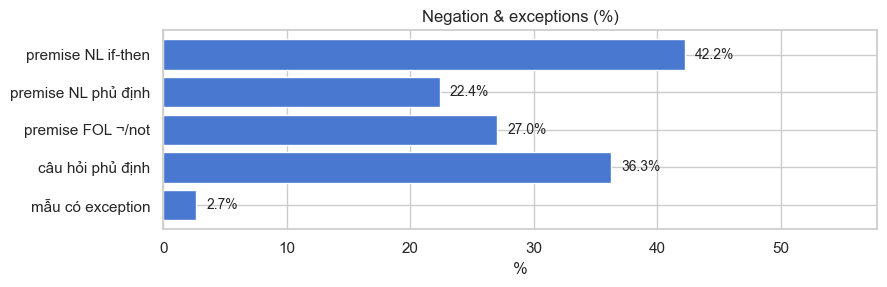

In [18]:
NEG_NL = re.compile(r"\bnot\b|\bnever\b|\bwithout\b|\bno\s+", re.I)
NEG_FOL = re.compile(r"¬|\bnot\b|ForAll.*Not|\(not\s", re.I)
EXC = re.compile(r"unless|except|only if|provided that", re.I)
IF_THEN = re.compile(r"if\b.*\bthen\b", re.I)
NUM_Q = re.compile(r"\d|more than|at least|GPA|credit|percent|%", re.I)

all_nl = [p for r in records for p in r["premises-NL"]]
all_fol = [p for r in records for p in get_fol(r)]

print("=== Negation & exceptions ===")
has_exc = [any(EXC.search(p) for p in r["premises-NL"]) for r in records]
a2_metrics = {
    "premise NL if-then": 100 * np.mean([bool(IF_THEN.search(p)) for p in all_nl]),
    "premise NL phủ định": 100 * np.mean([bool(NEG_NL.search(p)) for p in all_nl]),
    "premise FOL ¬/not": 100 * np.mean([bool(NEG_FOL.search(p)) for p in all_fol]),
    "câu hỏi phủ định": 100 * df_q["question"].str.contains(NEG_NL).mean(),
    "mẫu có exception": 100 * np.mean(has_exc),
}
for k, v in a2_metrics.items():
    print(f"{k}: {v:.1f}%")
plot_pct_bars(a2_metrics, "Negation & exceptions (%)", "A2_negation_exceptions.png")


=== Phân bố nhãn ===
answer_norm
No         300
Unknown    209
Yes        116
MCQ_A      105
MCQ_B       39
MCQ_C       20
MCQ_D       19
Name: count, dtype: int64

Tỷ lệ Unknown: 25.9%


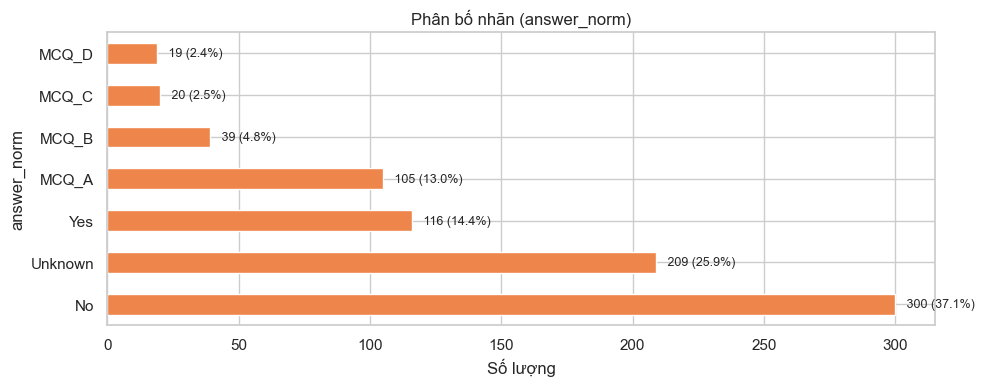

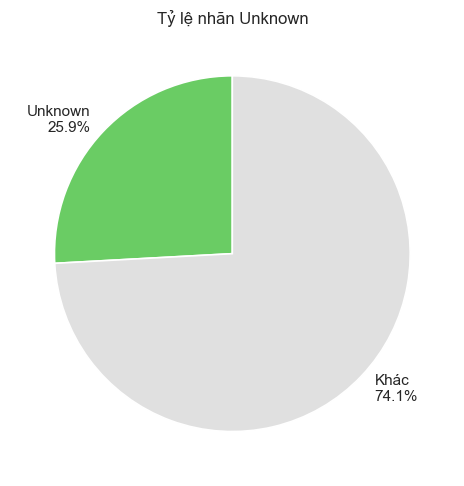


len(idx) theo nhãn (median):
answer_norm
MCQ_D      2.0
No         2.0
Unknown    2.0
Yes        2.0
MCQ_A      3.0
MCQ_B      3.0
MCQ_C      3.0
Name: n_premises_used, dtype: float64

Unknown theo loại câu:
is_mcq       False  True  All
answer_norm                  
False          417   182  599
True            32   177  209
All            449   359  808


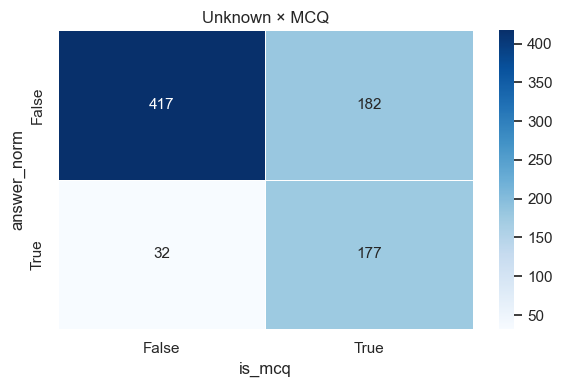

In [19]:
def norm_answer(a: str) -> str:
    a = str(a).strip()
    if a in {"Yes", "No", "Unknown", "Uncertain"}:
        return a
    if re.fullmatch(r"[A-D]", a):
        return f"MCQ_{a}"

    if len(a) <= 20:
        return "other_short"
    return "other_long"


df_q["answer_norm"] = df_q["answer"].apply(norm_answer)

print("=== Phân bố nhãn ===")
print(df_q["answer_norm"].value_counts())
pct_unknown = 100 * (df_q["answer_norm"] == "Unknown").mean()
print(f"\nTỷ lệ Unknown: {pct_unknown:.1f}%")
plot_count_dist(df_q["answer_norm"], "Phân bố nhãn (answer_norm)", "A3_answer_norm.png")
plot_binary_pie(pct_unknown, "Tỷ lệ nhãn Unknown", "A3_unknown_pie.png", yes_label="Unknown", no_label="Khác")

print("\nlen(idx) theo nhãn (median):")
print(df_q.groupby("answer_norm")["n_premises_used"].median().sort_values())

print("\nUnknown theo loại câu:")
unk = df_q["answer_norm"] == "Unknown"
ct_unk_mcq = pd.crosstab(unk, df_q["is_mcq"], margins=True)
print(ct_unk_mcq)
plot_heatmap_ct(ct_unk_mcq.iloc[:-1, :-1], "Unknown × MCQ", "A3_unknown_vs_mcq.png")


=== Số học trong NL ===
câu có số/so sánh: 20.5%
mẫu premise có ngưỡng: 64.2%


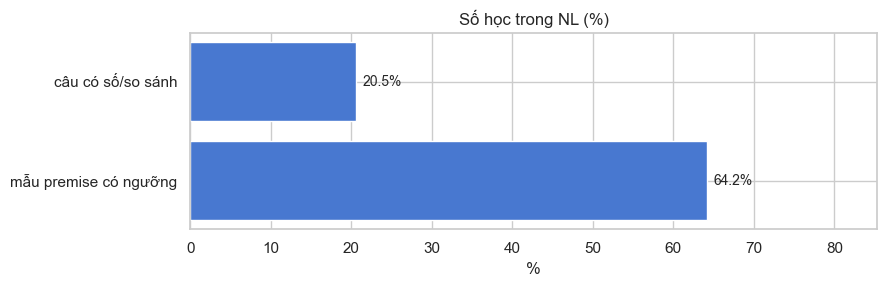


Unknown × có số:
has_numeric  False  True 
answer_norm              
False          472    127
True           170     39


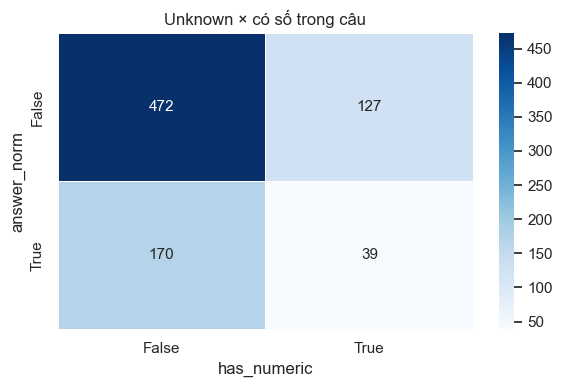

In [20]:
df_q["has_numeric"] = df_q["question"].str.contains(NUM_Q, regex=True)
rec_num_prem = [any(NUM_Q.search(p) for p in r["premises-NL"]) for r in records]

print("=== Số học trong NL ===")
a4_metrics = {
    "câu có số/so sánh": 100 * df_q["has_numeric"].mean(),
    "mẫu premise có ngưỡng": 100 * np.mean(rec_num_prem),
}
for k, v in a4_metrics.items():
    print(f"{k}: {v:.1f}%")
plot_pct_bars(a4_metrics, "Số học trong NL (%)", "A4_numeric.png")
print("\nUnknown × có số:")
ct_unk_num = pd.crosstab(df_q["answer_norm"] == "Unknown", df_q["has_numeric"])
print(ct_unk_num)
plot_heatmap_ct(ct_unk_num, "Unknown × có số trong câu", "A4_unknown_numeric.png")


## 6. Explanation & FOL challenges


=== FOL ===
1 % mẫu có FOL: 100.0%  [BTC: 99%]
2 Notation: ∀ unicode=2053, ForAll(...)=1629
3 FOL lỗi/encoding: 1629 premise
  → ForAll(x, (completed_core_curriculum(x) ∧ passed_science_assessment(x)) → qualif...
  → ForAll(x, (qualified_for_advanced_courses(x) ∧ completed_research_methodology(x)...
4 NL==FOL len: 97.3% mẫu khớp
5 universal=3671, existential=753, total premises=4470


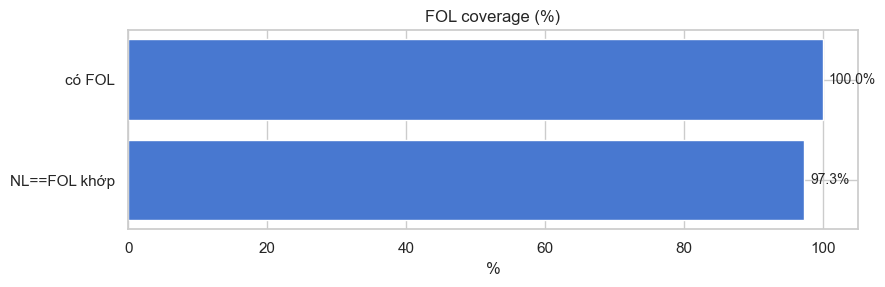

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14560\331151581.py:57: UserWarning: Glyph 8704 (\N{FOR ALL}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14560\331151581.py:58: UserWarning: Glyph 8704 (\N{FOR ALL}) missing from current font.
  plt.savefig(FIG_DIR / filename, dpi=120, bbox_inches="tight")
c:\Users\ASUS\anaconda3\envs\DS310_env_3_10\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8704 (\N{FOR ALL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


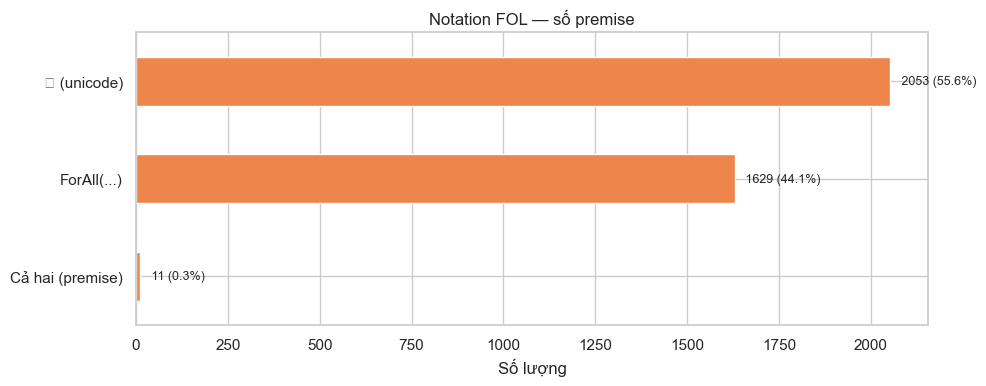

In [21]:
UNIV1 = re.compile(r"∀|ForAll|forall", re.I)
EXIST = re.compile(r"∃|Exists|exists", re.I)
FOL_BROKEN = re.compile(r"\ufffd|\bforall\s*\(", re.I)

fol_univ = sum(1 for p in all_fol if UNIV1.search(p))
fol_exist = sum(1 for p in all_fol if EXIST.search(p))
fol_broken = [p for p in all_fol if FOL_BROKEN.search(p)]
notation_forall_unicode = sum(1 for p in all_fol if "∀" in p)
notation_forall_word = sum(1 for p in all_fol if re.search(r"ForAll\s*\(", p))

print("=== FOL ===")
pct_has_fol = 100 * df_rec["has_fol"].mean()
pct_nl_fol_match = 100 * df_rec["nl_fol_match"].mean()
print(f"1 % mẫu có FOL: {pct_has_fol:.1f}%  [BTC: {BTC['fol_pct']}%]")
print(f"2 Notation: ∀ unicode={notation_forall_unicode}, ForAll(...)={notation_forall_word}")
print(f"3 FOL lỗi/encoding: {len(fol_broken)} premise")
if fol_broken[:2]:
    for p in fol_broken[:2]:
        print(f"  → {p[:80]}...")
print(f"4 NL==FOL len: {pct_nl_fol_match:.1f}% mẫu khớp")
print(f"5 universal={fol_univ}, existential={fol_exist}, total premises={len(all_fol)}")
plot_pct_bars(
    {"có FOL": pct_has_fol, "NL==FOL khớp": pct_nl_fol_match},
    "FOL coverage (%)",
    "B1_fol_coverage.png",
)
fol_notation_counts = pd.Series(
    {
        "∀ (unicode)": notation_forall_unicode,
        "ForAll(...)": notation_forall_word,
        "Cả hai (premise)": sum(
            1 for p in all_fol if "∀" in p and re.search(r"ForAll\s*\(", p)
        ),
    }
)
plot_count_dist(
    fol_notation_counts,
    "Notation FOL — số premise",
    "B1_fol_notation.png",
    top_n=None,
    horizontal=True,
    preaggregated=True,
)


In [22]:
df_q["exp_words"] = df_q["explanation"].str.split().str.len()
df_q["q_words"] = df_q["question"].str.split().str.len()

print("=== Độ dài explanation (từ) ===")
print(df_q["exp_words"].describe())
print(f"P50={df_q['exp_words'].median():.0f}, P90={df_q['exp_words'].quantile(0.9):.0f}")

print("\nTheo loại câu (median từ):")
for col, label in [("is_mcq", "MCQ"), ("is_yn", "Y/N"), ("is_open", "Open")]:
    sub = df_q.loc[df_q[col], "exp_words"]
    print(f"  {label}: median={sub.median():.0f}, n={len(sub)}")


=== Độ dài explanation (từ) ===
count    808.000000
mean      56.007426
std       37.618873
min       13.000000
25%       30.000000
50%       40.000000
75%       73.250000
max      220.000000
Name: exp_words, dtype: float64
P50=40, P90=112

Theo loại câu (median từ):
  MCQ: median=47, n=359
  Y/N: median=55, n=216
  Open: median=33, n=233


=== Trích dẫn premise ===
2 mean premise cite trong explanation: 2.87
Overlap cite ∩ idx: 89.7%
Cite nằm trong idx: 88.7%
Under-citation: 10.3%
Over-citation: 11.3%


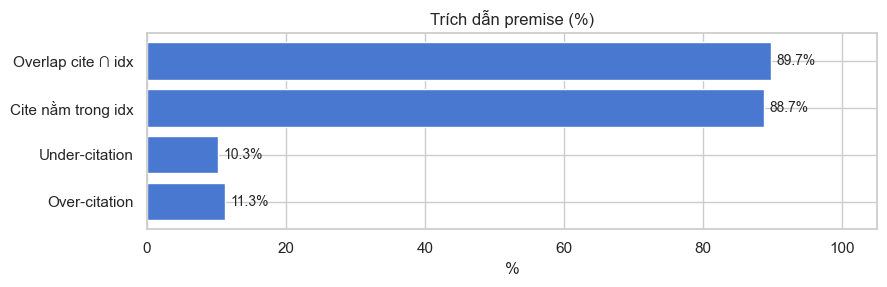

In [23]:
def cited_indices(text: str) -> set[int]:
    return {int(x) for x in re.findall(r"Premise\s+(\d+)", text, re.I)}


def idx_set(lst) -> set[int]:
    return set(lst)


df_q["cited_set"] = df_q["explanation"].apply(cited_indices)
df_q["idx_set"] = df_q["idx_used"].apply(idx_set)
df_q["cite_overlap"] = df_q.apply(
    lambda r: len(r["cited_set"] & r["idx_set"]) / len(r["idx_set"]) if r["idx_set"] else np.nan,
    axis=1,
)
df_q["cite_subset"] = df_q.apply(lambda r: r["cited_set"] <= r["idx_set"], axis=1)
df_q["under_cite"] = df_q.apply(
    lambda r: len(r["cited_set"]) < len(r["idx_set"]) if r["idx_set"] else False, axis=1
)
df_q["over_cite"] = df_q.apply(
    lambda r: len(r["cited_set"]) > len(r["idx_set"]) or bool(r["cited_set"] - r["idx_set"]),
    axis=1,
)

print("=== Trích dẫn premise ===")
print(f"2 mean premise cite trong explanation: {df_q['n_cited_in_exp'].mean():.2f}")
b4_metrics = {
    "Overlap cite ∩ idx": 100 * df_q["cite_overlap"].mean(),
    "Cite nằm trong idx": 100 * df_q["cite_subset"].mean(),
    "Under-citation": 100 * df_q["under_cite"].mean(),
    "Over-citation": 100 * df_q["over_cite"].mean(),
}
for k, v in b4_metrics.items():
    print(f"{k}: {v:.1f}%")
plot_pct_bars(b4_metrics, "Trích dẫn premise (%)", "B4_premise_citation.png")


In [24]:
df_q["answer_norm"].head()

0    MCQ_A
1      Yes
2    MCQ_C
3      Yes
4    MCQ_C
Name: answer_norm, dtype: object

1 MCQ answer trong explanation: 82.0% (150/183)
2 Y/N heuristic khớp explanation: 36.5%
Unknown + pattern abstain trong exp: 14.4%


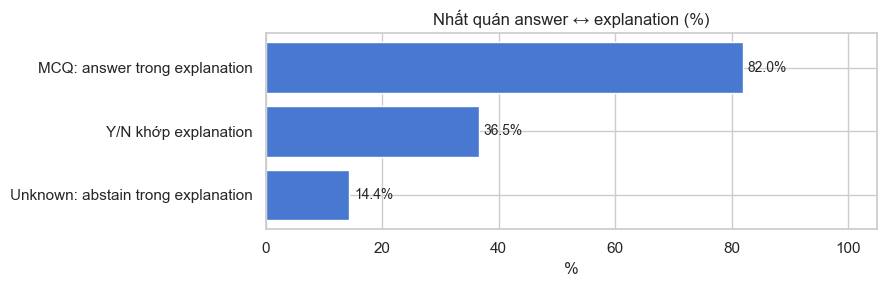

In [25]:

mcq = df_q["answer_norm"].str.startswith("MCQ_")
mcq_ok = df_q.loc[mcq].apply(
    lambda r: r["answer"].strip() in r["explanation"], axis=1
)
pct_mcq_ok = 100 * mcq_ok.mean() if mcq.sum() else 0.0
print(f"1 MCQ answer trong explanation: {pct_mcq_ok:.1f}% ({mcq_ok.sum()}/{mcq.sum()})")

yn = df_q["answer_norm"].isin(["Yes", "No"])
def yn_match(r):
    exp = r["explanation"].lower()
    if r["answer"] == "Yes":
        return "yes" in exp[-200:] or "holds" in exp[-200:] or "true" in exp[-200:]
    return "no" in exp[-200:] or "false" in exp[-200:] or "does not" in exp[-200:]

yn_ok = df_q.loc[yn].apply(yn_match, axis=1)
pct_yn_ok = 100 * yn_ok.mean() if yn.sum() else 0.0
print(f"2 Y/N heuristic khớp explanation: {pct_yn_ok:.1f}%")

unk = df_q["answer_norm"] == "Unknown"
unk_pat = re.compile(r"cannot|uncertain|unknown|not determine|insufficient", re.I)
unk_ok = df_q.loc[unk, "explanation"].str.contains(unk_pat)
pct_unk_ok = 100 * unk_ok.mean() if unk.sum() else 0.0
print(f"Unknown + pattern abstain trong exp: {pct_unk_ok:.1f}%")
b3_metrics = {
    "MCQ: answer trong explanation": pct_mcq_ok,
    "Y/N khớp explanation": pct_yn_ok,
    "Unknown: abstain trong explanation": pct_unk_ok,
}
plot_pct_bars(b3_metrics, "Nhất quán answer ↔ explanation (%)", "B3_answer_explanation.png")


## 6b. Chuẩn hóa FOL + câu hỏi (MCQ) + giải thích + đáp án

- **premises-FOL:** `ForAll` / `Exists` → `∀` / `∃`.
- **questions:** toàn bộ text câu hỏi (kể các dòng option A–D chứa công thức) — cùng hàm `normalize_fol`.
- **explanation:** cùng `normalize_fol` nếu có trích FOL.
- **Đáp án:** về **A/B/C/D/Yes/No/Unknown** (`canonicalize_answer`).

Bản đã norm → `records_norm` và `data/interim/eda/Logic_Based_Educational_Queries_normalized.json`.


In [26]:
import re

from evaluation.metrics import require_answer_label

# ---------- normalize helpers ----------
_FORALL_PAT = re.compile(r'ForAll\s*\((\w+),\s*(.+?)\)\s*$')
_EXISTS_PAT = re.compile(r'Exists\s*\((\w+),\s*(.+?)\)\s*$')


def _replace_quantifier(formula: str) -> str:
    """Một lượt thay ForAll/Exists ngoài cùng; gọi đệ quy cho nested."""
    f = formula.strip()
    m = _FORALL_PAT.fullmatch(f)
    if m:
        return f'\u2200{m.group(1)} ({_replace_quantifier(m.group(2))})'
    m = _EXISTS_PAT.fullmatch(f)
    if m:
        return f'\u2203{m.group(1)} ({_replace_quantifier(m.group(2))})'
    return f


def _find_matching_paren(s: str, start: int) -> int:
    """Tìm vị trí ) đóng khớp với ( tại start."""
    depth = 0
    for i in range(start, len(s)):
        if s[i] == '(':
            depth += 1
        elif s[i] == ')':
            depth -= 1
            if depth == 0:
                return i
    return -1


def normalize_fol(formula: str) -> str:
    """Thay ForAll(var, body) → ∀var (body) và Exists(var, body) → ∃var (body),
    xử lý nested tùy ý bằng cách tìm ) đóng khớp."""
    
    def _replace_one(s: str) -> tuple[str, bool]:
        """1 lượt quét — trả (chuỗi mới, có thay đổi không)."""
        for kw, sym in [('ForAll', '∀'), ('Exists', '∃')]:
            idx = s.find(kw + '(')
            if idx == -1:
                continue
            open_p = idx + len(kw)          # vị trí '('
            close_p = _find_matching_paren(s, open_p)
            if close_p == -1:
                continue
            inner = s[open_p + 1 : close_p]  # nội dung bên trong (...)
            # Tách var và body tại dấu ',' đầu tiên
            comma = inner.find(',')
            if comma == -1:
                continue
            var  = inner[:comma].strip()
            body = inner[comma + 1:].strip()
            replacement = f'{sym}{var} ({body})'
            s = s[:idx] + replacement + s[close_p + 1:]
            return s, True
        return s, False

    result = formula
    for _ in range(20):          # tối đa 20 vòng — đủ cho nested sâu
        result, changed = _replace_one(result)
        if not changed:
            break
    return result.strip()


def normalize_premises_fol(premises: list[str]) -> list[str]:
    """Áp dụng normalize_fol cho từng chuỗi trong premises-FOL."""
    return [normalize_fol(str(p)) for p in premises]


def canonicalize_answer(raw) -> str:
    """Chuẩn về một trong 7 nhãn A/B/C/D/Yes/No/Unknown (khớp pipeline train / CSV)."""
    v = str(raw).strip().split("\n", 1)[0].strip()
    try:
        return require_answer_label(v)
    except ValueError:
        pass
    vl = v.lower()
    if vl == "uncertain":
        return "Unknown"
    if vl in ("yes", "no", "unknown"):
        return {"yes": "Yes", "no": "No", "unknown": "Unknown"}[vl]
    if re.fullmatch(r"[ABCD]", v, flags=re.I):
        return v.upper()
    m = re.fullmatch(r"MCQ_([ABCD])", v, flags=re.I)
    if m:
        return m.group(1).upper()
    m = re.search(r"(?:option|choice|answer|đáp\s*án)\s*[:#.]?\s*([ABCD])\b", v, flags=re.I)
    if m:
        return m.group(1).upper()
    m = re.search(r"\(([ABCD])\)", v, flags=re.I)
    if m:
        return m.group(1).upper()
    if len(v) <= 12:
        m = re.search(r"\b([ABCD])\b", v, flags=re.I)
        if m:
            return m.group(1).upper()
    raise ValueError(f"Không chuẩn hóa được đáp án: {raw!r}")


# ---------- quick test ----------
_test_cases = [
    ('ForAll(x, RecognizedInnovative(x))',            '\u2200x (RecognizedInnovative(x))'),
    ('Exists(x, LearnedAboutCultures(x))',            '\u2203x (LearnedAboutCultures(x))'),
    ('ForAll(x, \u00acWellFunded(x) \u2192 \u00acMeetsAcademicStandards(x))',
                                                      '\u2200x (\u00acWellFunded(x) \u2192 \u00acMeetsAcademicStandards(x))'),
    ('Exists(x, AttendedFestival(x)) \u2192 Exists(y, LearnedAboutCultures(y))',
                                                      '\u2203x (AttendedFestival(x)) \u2192 \u2203y (LearnedAboutCultures(y))'),
    # Đã chuẩn → không thay đổi
    ('\u2200x (T(x) \u2192 U(x))',                    '\u2200x (T(x) \u2192 U(x))'),
]

print('=== Test normalize_fol ===')
all_pass = True
for inp, expected in _test_cases:
    out = normalize_fol(inp)
    ok = out == expected
    if not ok:
        all_pass = False
    status = '\u2705' if ok else '\u274c'
    print(f'  {status}  IN : {inp}')
    if not ok:
        print(f'       OUT: {out}')
        print(f'       EXP: {expected}')
print(f'\nKết quả: {"TẤT CẢ PASS" if all_pass else "CÓ LỖI — xem chi tiết trên"}')


=== Test normalize_fol ===
  ✅  IN : ForAll(x, RecognizedInnovative(x))
  ✅  IN : Exists(x, LearnedAboutCultures(x))
  ✅  IN : ForAll(x, ¬WellFunded(x) → ¬MeetsAcademicStandards(x))
  ✅  IN : Exists(x, AttendedFestival(x)) → Exists(y, LearnedAboutCultures(y))
  ✅  IN : ∀x (T(x) → U(x))

Kết quả: TẤT CẢ PASS


=== Stats trước chuẩn hóa ===
  Tổng premises FOL       : 4470
  ForAll(word)            : 1629 (36.4%)
  Exists(word)            : 369 (8.3%)
  ∀ (symbol)              : 2053 (45.9%)
  ∃ (symbol)              : 384 (8.6%)
  Records có cả 2 notation: 72


C:\Users\ASUS\AppData\Local\Temp\ipykernel_14560\3501886386.py:42: UserWarning: Glyph 8707 (\N{THERE EXISTS}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14560\3501886386.py:42: UserWarning: Glyph 8704 (\N{FOR ALL}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14560\3501886386.py:43: UserWarning: Glyph 8707 (\N{THERE EXISTS}) missing from current font.
  plt.savefig(FIG_DIR / "B1b_fol_notation_before.png", dpi=120, bbox_inches="tight")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14560\3501886386.py:43: UserWarning: Glyph 8704 (\N{FOR ALL}) missing from current font.
  plt.savefig(FIG_DIR / "B1b_fol_notation_before.png", dpi=120, bbox_inches="tight")
c:\Users\ASUS\anaconda3\envs\DS310_env_3_10\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8707 (\N{THERE EXISTS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ASUS\anaconda3\envs\DS310_env_3_10\

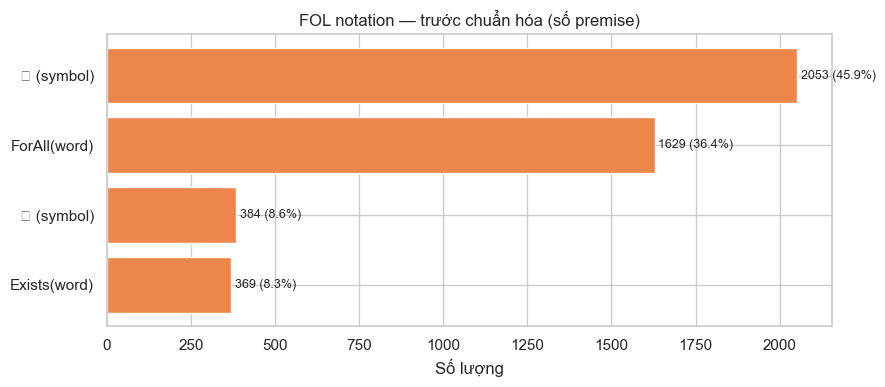

In [27]:
# ---------- Stats before normalization ----------
_FORALL_WORD = re.compile(r'ForAll\s*\(')
_EXISTS_WORD = re.compile(r'Exists\s*\(')

n_forall_word  = sum(1 for p in all_fol if _FORALL_WORD.search(p))
n_exists_word  = sum(1 for p in all_fol if _EXISTS_WORD.search(p))
n_forall_sym   = sum(1 for p in all_fol if '\u2200' in p)
n_exists_sym   = sum(1 for p in all_fol if '\u2203' in p)
n_mixed_record = sum(
    1 for r in records
    if get_fol(r) and
       any(_FORALL_WORD.search(p) or _EXISTS_WORD.search(p) for p in get_fol(r)) and
       any('\u2200' in p or '\u2203' in p for p in get_fol(r))
)

print('=== Stats trước chuẩn hóa ===')
print(f'  Tổng premises FOL       : {len(all_fol)}')
print(f'  ForAll(word)            : {n_forall_word} ({100*n_forall_word/len(all_fol):.1f}%)')
print(f'  Exists(word)            : {n_exists_word} ({100*n_exists_word/len(all_fol):.1f}%)')
print(f'  ∀ (symbol)              : {n_forall_sym} ({100*n_forall_sym/len(all_fol):.1f}%)')
print(f'  ∃ (symbol)              : {n_exists_sym} ({100*n_exists_sym/len(all_fol):.1f}%)')
print(f'  Records có cả 2 notation: {n_mixed_record}')

pre_stats = pd.Series({
    'ForAll(word)': n_forall_word,
    'Exists(word)': n_exists_word,
    '∀ (symbol)' : n_forall_sym,
    '∃ (symbol)' : n_exists_sym,
})

# Vẽ thủ công để dùng đúng total
fig, ax = plt.subplots(figsize=(9, 4))
pre_stats_sorted = pre_stats.sort_values(ascending=True)
bars = ax.barh(pre_stats_sorted.index, pre_stats_sorted.values,
               color=sns.color_palette("muted")[1], edgecolor="white")
total = len(all_fol)  # 4470 — đúng denominator
for bar, v in zip(bars, pre_stats_sorted.values):
    ax.text(v + 10, bar.get_y() + bar.get_height()/2,
            f"{v} ({100*v/total:.1f}%)", va="center", fontsize=9)
ax.set_title("FOL notation — trước chuẩn hóa (số premise)")
ax.set_xlabel("Số lượng")
plt.tight_layout()
plt.savefig(FIG_DIR / "B1b_fol_notation_before.png", dpi=120, bbox_inches="tight")
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14560\3100304068.py:100: UserWarning: Glyph 8704 (\N{FOR ALL}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14560\3100304068.py:100: UserWarning: Glyph 8707 (\N{THERE EXISTS}) missing from current font.
  plt.tight_layout()


Records FOL thay đổi : 222 / 411
Premises FOL thay đổi: 1915 / 4470
Câu hỏi entry đổi   : 17 | Records có câu hỏi đổi: 15
Giải thích entry đổi: 3 | Records có expl đổi: 2
Đáp án entry đổi    : 0 | Records có đáp án đổi: 0
Còn ForAll/Exists sau norm: 0  (kỳ vọng: 0)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_14560\3100304068.py:101: UserWarning: Glyph 8704 (\N{FOR ALL}) missing from current font.
  plt.savefig(FIG_DIR / "B1b_fol_notation_breakdown.png", dpi=120, bbox_inches="tight")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14560\3100304068.py:101: UserWarning: Glyph 8707 (\N{THERE EXISTS}) missing from current font.
  plt.savefig(FIG_DIR / "B1b_fol_notation_breakdown.png", dpi=120, bbox_inches="tight")


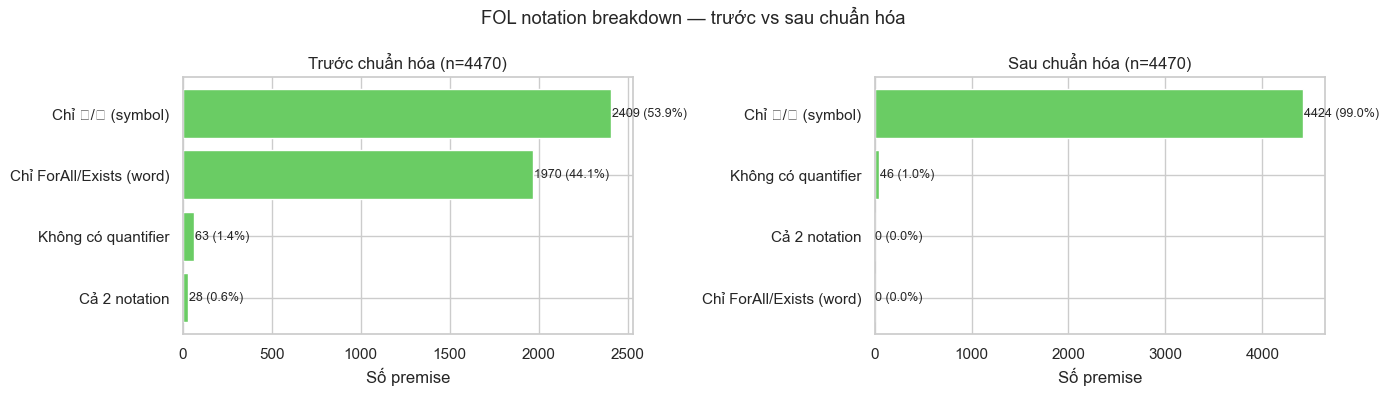

In [28]:
# ---------- Apply normalization (FOL + câu hỏi/giải thích/đáp án) ----------
records_norm = []
n_changed_premise = 0
n_changed_record  = 0
n_changed_answer = 0
n_records_with_answer_edit = 0
n_changed_question = 0
n_records_with_question_edit = 0
n_changed_explanation = 0
n_records_with_explanation_edit = 0

for rec in records:
    rec_new = dict(rec)
    ans_orig = [str(x) for x in rec.get("answers", [])]
    ans_new = [canonicalize_answer(x) for x in ans_orig]
    if ans_new != ans_orig:
        n_records_with_answer_edit += 1
        n_changed_answer += sum(1 for a, b in zip(ans_orig, ans_new) if a != b)
    rec_new["answers"] = ans_new

    q_orig = [str(x) for x in rec.get("questions", [])]
    q_new = [normalize_fol(x) for x in q_orig]
    if q_new != q_orig:
        n_records_with_question_edit += 1
        n_changed_question += sum(1 for a, b in zip(q_orig, q_new) if a != b)
    rec_new["questions"] = q_new

    exp_orig = [str(x) for x in rec.get("explanation", [])]
    exp_new = [normalize_fol(x) for x in exp_orig]
    if exp_new != exp_orig:
        n_records_with_explanation_edit += 1
        n_changed_explanation += sum(1 for a, b in zip(exp_orig, exp_new) if a != b)
    rec_new["explanation"] = exp_new

    fol_orig = get_fol(rec)
    if fol_orig:
        fol_norm = normalize_premises_fol(fol_orig)
        changed = sum(1 for a, b in zip(fol_orig, fol_norm) if a != b)
        if changed:
            n_changed_premise += changed
            n_changed_record += 1
        rec_new['premises-FOL'] = fol_norm
    records_norm.append(rec_new)

print(f'Records FOL thay đổi : {n_changed_record} / {len(records)}')
print(f'Premises FOL thay đổi: {n_changed_premise} / {len(all_fol)}')
print(f'Câu hỏi entry đổi   : {n_changed_question} | Records có câu hỏi đổi: {n_records_with_question_edit}')
print(f'Giải thích entry đổi: {n_changed_explanation} | Records có expl đổi: {n_records_with_explanation_edit}')
print(f'Đáp án entry đổi    : {n_changed_answer} | Records có đáp án đổi: {n_records_with_answer_edit}')

# ---------- Stats sau norm ----------
all_fol_norm = [p for r in records_norm for p in get_fol(r)]
remain_word  = sum(1 for p in all_fol_norm if _FORALL_WORD.search(p) or _EXISTS_WORD.search(p))
print(f'Còn ForAll/Exists sau norm: {remain_word}  (kỳ vọng: 0)')

n_forall_sym_after = sum(1 for p in all_fol_norm if '\u2200' in p)
n_exists_sym_after = sum(1 for p in all_fol_norm if '\u2203' in p)
n_both_after = sum(
    1 for p in all_fol_norm
    if (_FORALL_WORD.search(p) or _EXISTS_WORD.search(p))
    and ('\u2200' in p or '\u2203' in p)
)

# ---------- So sánh trước / sau ----------
def _breakdown(fol_list, forall_w_pat, exists_w_pat):
    n_fw  = sum(1 for p in fol_list if forall_w_pat.search(p))
    n_ew  = sum(1 for p in fol_list if exists_w_pat.search(p))
    n_fs  = sum(1 for p in fol_list if '\u2200' in p)
    n_es  = sum(1 for p in fol_list if '\u2203' in p)
    n_b   = sum(1 for p in fol_list
                if (forall_w_pat.search(p) or exists_w_pat.search(p))
                and ('\u2200' in p or '\u2203' in p))
    n_none = len(fol_list) - n_fw - n_ew - n_fs - n_es + n_b
    return pd.Series({
        'Chỉ ForAll/Exists (word)': n_fw + n_ew - n_b,
        'Chỉ ∀/∃ (symbol)'        : n_fs + n_es - n_b,
        'Cả 2 notation'            : n_b,
        'Không có quantifier'      : max(n_none, 0),
    })

before = _breakdown(all_fol,      _FORALL_WORD, _EXISTS_WORD)
after  = _breakdown(all_fol_norm, _FORALL_WORD, _EXISTS_WORD)
total  = len(all_fol)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, data, title in [
    (axes[0], before, f'Trước chuẩn hóa (n={total})'),
    (axes[1], after,  f'Sau chuẩn hóa (n={total})'),
]:
    s = data.sort_values(ascending=True)
    bars = ax.barh(s.index, s.values,
                   color=sns.color_palette("muted")[2], edgecolor="white")
    for bar, v in zip(bars, s.values):
        ax.text(v + 5, bar.get_y() + bar.get_height()/2,
                f"{v} ({100*v/total:.1f}%)", va="center", fontsize=9)
    ax.set_title(title)
    ax.set_xlabel("Số premise")

plt.suptitle("FOL notation breakdown — trước vs sau chuẩn hóa")
plt.tight_layout()
plt.savefig(FIG_DIR / "B1b_fol_notation_breakdown.png", dpi=120, bbox_inches="tight")
plt.show()

Các mẫu ko có định lượng vị từ (no quaitifier)

In [29]:
no_quantifier = [p for p in all_fol_norm 
                 if not _FORALL_WORD.search(p) 
                 and not _EXISTS_WORD.search(p)
                 and '∀' not in p 
                 and '∃' not in p]

print(f"Số premise không có quantifier: {len(no_quantifier)}")
print("=" * 60)
for i, p in enumerate(no_quantifier, 1):
    print(f"{i:2d}. {p}")

Số premise không có quantifier: 239
 1. completed_core_curriculum(Sophia)
 2. passed_science_assessment(Sophia)
 3. completed_research_methodology(Sophia)
 4. completed_capstone_project(Sophia)
 5. completed_community_service(Sophia)
 6. completed_core_curriculum(Sophia)
 7. passed_science_assessment(Sophia)
 8. completed_research_methodology(Sophia)
 9. completed_capstone_project(Sophia)
10. completed_community_service(Sophia)
11. completed_required_courses(John)
12. gpa_above_3_5(John)
13. completed_thesis(John)
14. completed_pedagogical_training(John)
15. holds_phd(John)
16. has_at_least_three_publications(John)
17. has_positive_evaluation(John)
18. taught_min_five_years(John)
19. has_publications(John)
20. completed_ethics_training(John)
21. has_departmental_endorsement(John)
22. passed_vehicle_inspection(John)
23. has_appropriate_license(John)
24. completed_hazmat_training(John)
25. ¬received_safety_endorsement(John)
26. has_interstate_permit(John)
27. higher(MSc, BA)
28. higher(P

In [30]:
# ---------- Export normalized JSON ----------
NORM_PATH = OUT_DIR / 'Logic_Based_Educational_Queries_normalized.json'
with open(NORM_PATH, 'w', encoding='utf-8') as f:
    json.dump(records_norm, f, ensure_ascii=False, indent=2)

print(f'Đã lưu: {NORM_PATH.resolve()}')
print(f'Size  : {NORM_PATH.stat().st_size / 1024:.1f} KB')

# Spot-check: 3 premise FOL đã đổi
print('\n=== Spot-check FOL (tối đa 3) ===')
shown = 0
for orig_rec, norm_rec in zip(records, records_norm):
    for orig_p, norm_p in zip(get_fol(orig_rec), get_fol(norm_rec)):
        if orig_p != norm_p:
            print(f'  BEFORE: {orig_p}')
            print(f'  AFTER : {norm_p}')
            print()
            shown += 1
            if shown >= 3:
                break
    if shown >= 3:
        break

# Spot-check: câu hỏi MCQ (snippet) — option thường chứa ForAll/Exists
print('\n=== Spot-check câu hỏi (tối đa 2, snippet 500 ký tự) ===')
shown_q = 0
for orig_rec, norm_rec in zip(records, records_norm):
    for oq, nq in zip(orig_rec.get("questions", []), norm_rec.get("questions", [])):
        oqs, nqs = str(oq), str(nq)
        if oqs != nqs:
            print('  BEFORE:', oqs[:500] + ('…' if len(oqs) > 500 else ''))
            print('  AFTER :', nqs[:500] + ('…' if len(nqs) > 500 else ''))
            print()
            shown_q += 1
            if shown_q >= 2:
                break
    if shown_q >= 2:
        break
if shown_q == 0:
    print('  (không đổi text câu hỏi — không còn ForAll(/Exists( cần thay trong phần đã quét)')

# Spot-check: 3 đáp án đã đổi
print('=== Spot-check đáp án (tối đa 3) ===')
shown_a = 0
for orig_rec, norm_rec in zip(records, records_norm):
    for oa, na in zip(orig_rec.get("answers", []), norm_rec.get("answers", [])):
        if str(oa).strip() != str(na).strip():
            print(f'  BEFORE: {oa!r}')
            print(f'  AFTER : {na!r}')
            print()
            shown_a += 1
            if shown_a >= 3:
                break
    if shown_a >= 3:
        break
if shown_a == 0:
    print('  (không có thay đổi đáp án — đã đúng 7 nhãn từ trước)')

print('Dùng file normalized cho pipeline SFT thay cho file raw.')


Đã lưu: E:\exact_2026\Exact_2026_Laplace-s_Red_Devils\Logic_Based_Educational_Queries_Project\data\interim\eda\Logic_Based_Educational_Queries_normalized.json
Size  : 1251.1 KB

=== Spot-check FOL (tối đa 3) ===
  BEFORE: ForAll(x, (completed_core_curriculum(x) ∧ passed_science_assessment(x)) → qualified_for_advanced_courses(x))
  AFTER : ∀x ((completed_core_curriculum(x) ∧ passed_science_assessment(x)) → qualified_for_advanced_courses(x))

  BEFORE: ForAll(x, (qualified_for_advanced_courses(x) ∧ completed_research_methodology(x)) → eligible_for_international_program(x))
  AFTER : ∀x ((qualified_for_advanced_courses(x) ∧ completed_research_methodology(x)) → eligible_for_international_program(x))

  BEFORE: ForAll(x, passed_language_proficiency(x) → eligible_for_international_program(x))
  AFTER : ∀x (passed_language_proficiency(x) → eligible_for_international_program(x))


=== Spot-check câu hỏi (tối đa 2, snippet 500 ký tự) ===
  BEFORE: Based on the above premises, which statement ca

## 7. Check Duplicate


In [31]:
from collections import defaultdict

dup_q = df_q["question"].duplicated().sum()
prem_key = [tuple(r["premises-NL"]) for r in records]
dup_prem = len(prem_key) - len(set(prem_key))
print(f"Câu hỏi trùng exact: {dup_q}")
print(f"Bộ premise-NL trùng: {dup_prem} mẫu (record thừa)")


def _record_json(rec: dict) -> dict:
    out = {
        "idx": rec["idx"],
        "premises-NL": rec["premises-NL"],
        "questions": rec["questions"],
        "answers": rec["answers"],
        "explanation": rec["explanation"],
    }
    fol = get_fol(rec)
    if fol:
        out["premises-FOL"] = fol
    return out


SEP_DUP = "=" * 72

dup_q_mask = df_q["question"].duplicated(keep=False)
if dup_q_mask.any():
    print(f"\n{SEP_DUP}")
    print("Mẫu câu hỏi trùng (exact) — full JSON record")
    print(SEP_DUP)
    for qtext, sub in df_q.loc[dup_q_mask].groupby("question", sort=False):
        locs = list(sub[["record_id", "q_idx"]].itertuples(index=False, name=None))
        print(f"\n--- {len(sub)} câu trùng @ {locs} ---")
        preview = qtext if len(qtext) <= 120 else qtext[:120] + "..."
        print(f"Question: {preview}")
        for rid in dict.fromkeys(sub["record_id"]):
            print(f"\n[record_id={rid}]")
            print(json.dumps(_record_json(records[rid]), ensure_ascii=False, indent=2))
else:
    print("\n(Không có câu hỏi trùng exact)")

prem_groups: dict[tuple, list[int]] = defaultdict(list)
for rid, key in enumerate(prem_key):
    prem_groups[key].append(rid)
dup_prem_groups = [rids for rids in prem_groups.values() if len(rids) > 1]
if dup_prem_groups:
    print(f"\n{SEP_DUP}")
    print(f"Mẫu premises-NL trùng — {len(dup_prem_groups)} nhóm — full JSON")
    print(SEP_DUP)
    for gi, rids in enumerate(dup_prem_groups, start=1):
        n_nl = len(records[rids[0]]["premises-NL"])
        print(f"\n--- Nhóm {gi}: record_id={rids} | {n_nl} premise-NL ---")
        for rid in rids:
            print(f"\n[record_id={rid}]")
            print(json.dumps(_record_json(records[rid]), ensure_ascii=False, indent=2))
else:
    print("\n(Không có bộ premises-NL trùng)")


Câu hỏi trùng exact: 20
Bộ premise-NL trùng: 10 mẫu (record thừa)

Mẫu câu hỏi trùng (exact) — full JSON record

--- 2 câu trùng @ [(1, 1), (2, 1)] ---
Question: Does Sophia qualify for the university scholarship, according to the premises?

[record_id=1]
{
  "idx": [
    [
      1,
      2,
      4,
      5,
      7,
      8,
      9,
      10,
      11
    ],
    [
      1,
      2,
      4,
      5,
      7,
      8,
      9,
      10,
      11
    ]
  ],
  "premises-NL": [
    "Students who have completed the core curriculum and passed the science assessment are qualified for advanced courses.",
    "Students who are qualified for advanced courses and have completed research methodology are eligible for the international program.",
    "Students who have passed the language proficiency exam are eligible for the international program.",
    "Students who are eligible for the international program and have completed a capstone project are awarded an honors diploma.",
    "Students wh

## 8. Visualizations tổng hợp


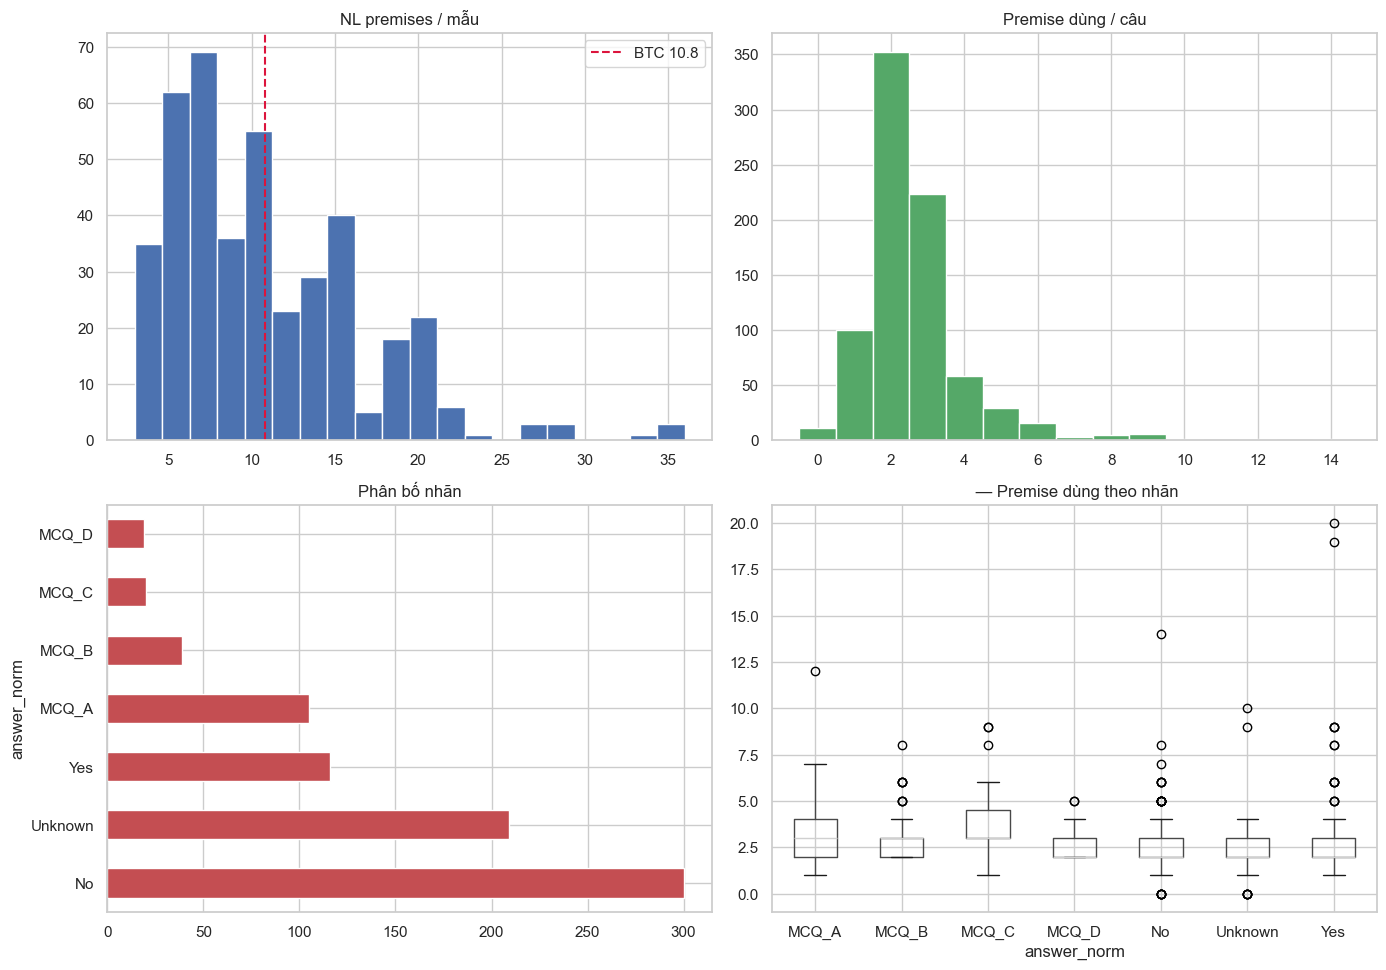

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df_rec["n_premises_nl"].hist(ax=axes[0, 0], bins=20, color="#4C72B0", edgecolor="white")
axes[0, 0].axvline(BTC["nl_per_record"], color="crimson", ls="--", label=f"BTC {BTC['nl_per_record']}")
axes[0, 0].set_title("NL premises / mẫu")
axes[0, 0].legend()

df_q["n_premises_used"].hist(ax=axes[0, 1], bins=range(0, 16), color="#55A868", edgecolor="white", align="left")
axes[0, 1].set_title("Premise dùng / câu")

df_q["answer_norm"].value_counts().plot(kind="barh", ax=axes[1, 0], color="#C44E52")
axes[1, 0].set_title("Phân bố nhãn")

df_q.boxplot(column="n_premises_used", by="answer_norm", ax=axes[1, 1])
axes[1, 1].set_title(" — Premise dùng theo nhãn")
plt.suptitle("")

plt.tight_layout()
plt.savefig(FIG_DIR / "EDA_summary_Logic.png", dpi=120, bbox_inches="tight")
plt.show()


## 8b. Kiem tra nhat quan dap an theo loai cau hoi

**Van de phat hien:** Nhieu cau trac nghiem 4 dap an (A/B/C/D) co `answer = "Unknown"` thay vi chon 1 trong 4 option.

Slide BTC (slide 17): *Ground-truth answers = Yes/No/Uncertain or specific values.*

Slide 19 (Key Challenges): *Distinguishing between "No" and "Uncertain" when information is incomplete.*

**2 bieu do:**
1. **MCQ 4 dap an**: Phan phoi answer (A/B/C/D vs Unknown)
2. **Cac dang con lai** (Yes/No, Open-ended): Phan phoi answer

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14560\526076609.py:78: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14560\526076609.py:79: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from current font.
  fig.savefig(FIG_DIR / "answer_consistency_check.png", dpi=150, bbox_inches="tight")
c:\Users\ASUS\anaconda3\envs\DS310_env_3_10\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


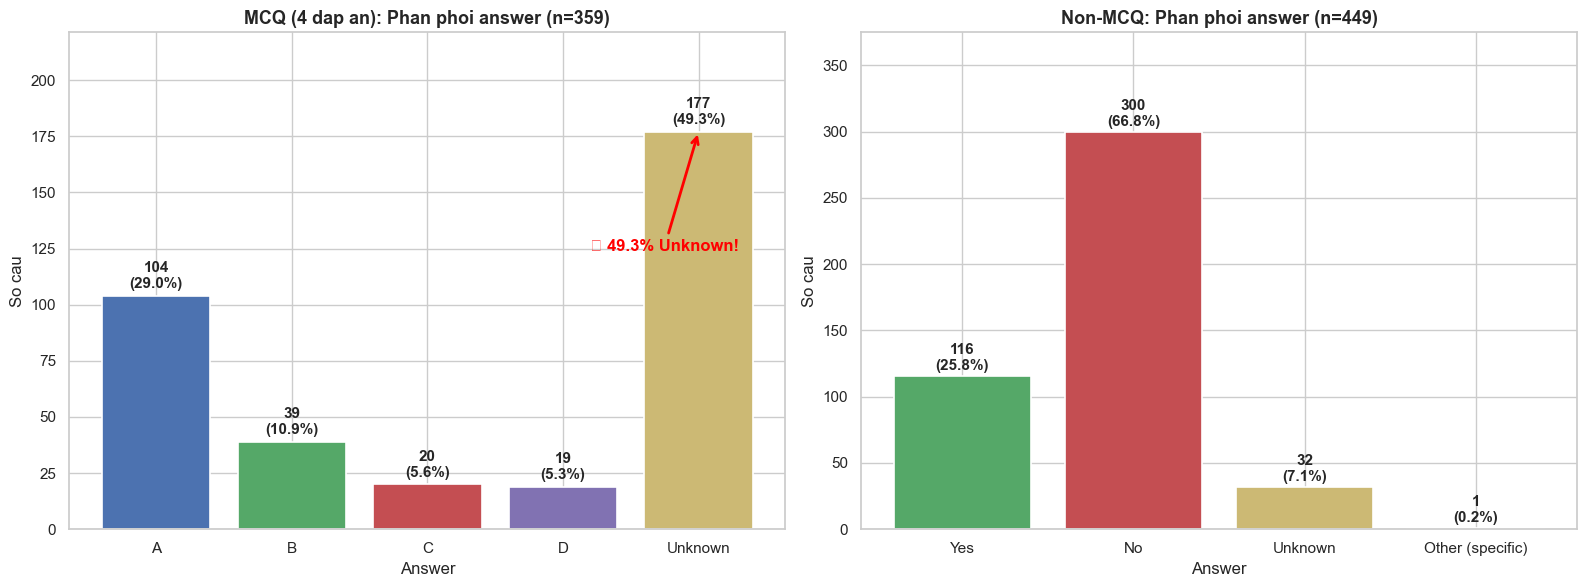

TOM TAT NHAT QUAN DAP AN
MCQ (4 dap an):  359 cau
  A: 104, B: 39, C: 20, D: 19
  Unknown: 177 (49.3%)
  => 49.3% MCQ khong chon A/B/C/D ma tra loi Unknown

Non-MCQ: 449 cau
  Yes: 116 (25.8%)
  No: 300 (66.8%)
  Unknown: 32 (7.1%)
  Other (specific): 1 (0.2%)
  Chi tiet Other: {'A': 1}


In [33]:
# === 8b. Answer consistency check ===
import re
from collections import Counter

# Reload raw data
with open(DATA_PATH, encoding="utf-8") as f:
    _raw = json.load(f)

# Classify questions
MCQ_RE = re.compile(r"\nA[\.\)]")  # has A. B. C. D. options

mcq_answers, other_answers = [], []
for rec in _raw:
    for q, a in zip(rec.get("questions", []), rec.get("answers", [])):
        a_str = str(a).strip()
        if MCQ_RE.search(q):
            mcq_answers.append(a_str)
        else:
            other_answers.append(a_str)

mcq_counter = Counter(mcq_answers)
other_counter = Counter(other_answers)

# --- Figure: 2 subplots ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- Chart 1: MCQ (4 options A/B/C/D) ----
ax1 = axes[0]
mcq_labels = ["A", "B", "C", "D", "Unknown"]
mcq_vals = [mcq_counter.get(l, 0) for l in mcq_labels]
colors_mcq = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]
bars1 = ax1.bar(mcq_labels, mcq_vals, color=colors_mcq, edgecolor="white", linewidth=1.2)

# Annotate bars
total_mcq = sum(mcq_vals)
for bar, val in zip(bars1, mcq_vals):
    pct = val / total_mcq * 100 if total_mcq else 0
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f"{val}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax1.set_title(f"MCQ (4 dap an): Phan phoi answer (n={total_mcq})", fontsize=13, fontweight="bold")
ax1.set_xlabel("Answer")
ax1.set_ylabel("So cau")
ax1.set_ylim(0, max(mcq_vals) * 1.25)

# Highlight Unknown bar
unknown_pct = mcq_counter.get("Unknown", 0) / total_mcq * 100 if total_mcq else 0
if unknown_pct > 30:
    ax1.annotate(f"⚠ {unknown_pct:.1f}% Unknown!",
                xy=(4, mcq_counter.get("Unknown", 0)),
                xytext=(3.2, mcq_counter.get("Unknown", 0) * 0.7),
                fontsize=12, color="red", fontweight="bold",
                arrowprops=dict(arrowstyle="->", color="red", lw=2))

# ---- Chart 2: Non-MCQ (Yes/No/Unknown/Other) ----
ax2 = axes[1]
canonical = ["Yes", "No", "Unknown"]
other_specific = {k: v for k, v in other_counter.items() if k not in canonical}
non_mcq_labels = canonical + (["Other (specific)"] if other_specific else [])
non_mcq_vals = [other_counter.get(l, 0) for l in canonical]
if other_specific:
    non_mcq_vals.append(sum(other_specific.values()))

colors_other = ["#55A868", "#C44E52", "#CCB974", "#8172B2"][:len(non_mcq_labels)]
bars2 = ax2.bar(non_mcq_labels, non_mcq_vals, color=colors_other, edgecolor="white", linewidth=1.2)

total_other = sum(non_mcq_vals)
for bar, val in zip(bars2, non_mcq_vals):
    pct = val / total_other * 100 if total_other else 0
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f"{val}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax2.set_title(f"Non-MCQ: Phan phoi answer (n={total_other})", fontsize=13, fontweight="bold")
ax2.set_xlabel("Answer")
ax2.set_ylabel("So cau")
ax2.set_ylim(0, max(non_mcq_vals) * 1.25)

plt.tight_layout()
fig.savefig(FIG_DIR / "answer_consistency_check.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Summary stats ---
print("=" * 60)
print("TOM TAT NHAT QUAN DAP AN")
print("=" * 60)
print(f"MCQ (4 dap an):  {total_mcq} cau")
print(f"  A: {mcq_counter.get('A',0)}, B: {mcq_counter.get('B',0)}, C: {mcq_counter.get('C',0)}, D: {mcq_counter.get('D',0)}")
print(f"  Unknown: {mcq_counter.get('Unknown',0)} ({unknown_pct:.1f}%)")
print(f"  => {unknown_pct:.1f}% MCQ khong chon A/B/C/D ma tra loi Unknown")
print()
print(f"Non-MCQ: {total_other} cau")
for l, v in zip(non_mcq_labels, non_mcq_vals):
    print(f"  {l}: {v} ({v/total_other*100:.1f}%)")
if other_specific:
    top_other = dict(sorted(other_specific.items(), key=lambda x: -x[1])[:10])
    print(f"  Chi tiet Other: {top_other}")


## 8c. Xoa mau Other + Re-export Stratified + Phan phoi nhan train/dev/test

1. **Xoa** cac cau Non-MCQ co answer khong phai Yes/No/Unknown (vd. answer = 'A' trong dang Yes/No)
2. **Re-export** voi stratified split (dam bao MCQ/Non-MCQ + Unknown phan bo deu)
3. **6 bieu do**: 3 MCQ (train/dev/test) + 3 Non-MCQ (train/dev/test)


In [34]:
# === 8c. Xoa mau "Other" tu records_norm + Re-export stratified ===
import re
import importlib
from data import ingestion
importlib.reload(ingestion)  # reload de lay code stratify moi
from data.ingestion import export_from_records

MCQ_RE = re.compile(r"\nA[\\.)\\)]")
VALID_NON_MCQ = {"Yes", "No", "Unknown"}

# --- Dem va xoa "Other" ---
removed_total = 0
records_clean = []

for rec in records_norm:
    questions = rec.get("questions", [])
    answers = [str(a).strip() for a in rec.get("answers", [])]
    explanations = rec.get("explanation", [])
    idx_lists = rec.get("idx", [])

    keep_indices = []
    for i, (q, a) in enumerate(zip(questions, answers)):
        is_mcq = bool(MCQ_RE.search(q))
        if not is_mcq and a not in VALID_NON_MCQ:
            removed_total += 1
            continue
        keep_indices.append(i)

    if len(keep_indices) == len(questions):
        records_clean.append(rec)
    elif len(keep_indices) > 0:
        rec_new = dict(rec)
        rec_new["questions"] = [questions[i] for i in keep_indices]
        rec_new["answers"] = [answers[i] for i in keep_indices]
        if explanations:
            rec_new["explanation"] = [explanations[i] for i in keep_indices if i < len(explanations)]
        if idx_lists:
            rec_new["idx"] = [idx_lists[i] for i in keep_indices if i < len(idx_lists)]
        records_clean.append(rec_new)

n_q_before = sum(len(r["questions"]) for r in records_norm)
n_q_after = sum(len(r["questions"]) for r in records_clean)

print(f"Records: {len(records_norm)} -> {len(records_clean)}")
print(f"Questions: {n_q_before} -> {n_q_after} (xoa {removed_total} mau 'Other')")
print()

# --- Re-export voi stratified split ---
SFT_PROCESSED = PROJECT_ROOT / "data" / "processed"
export_from_records(
    records_clean,
    SFT_PROCESSED,
    expected_questions=None,
    stratify=True,
)
print(f"Re-exported stratified -> {SFT_PROCESSED}")


Records: 411 -> 410
Questions: 808 -> 807 (xoa 1 mau 'Other')

Re-exported stratified -> E:\exact_2026\Exact_2026_Laplace-s_Red_Devils\Logic_Based_Educational_Queries_Project\data\processed


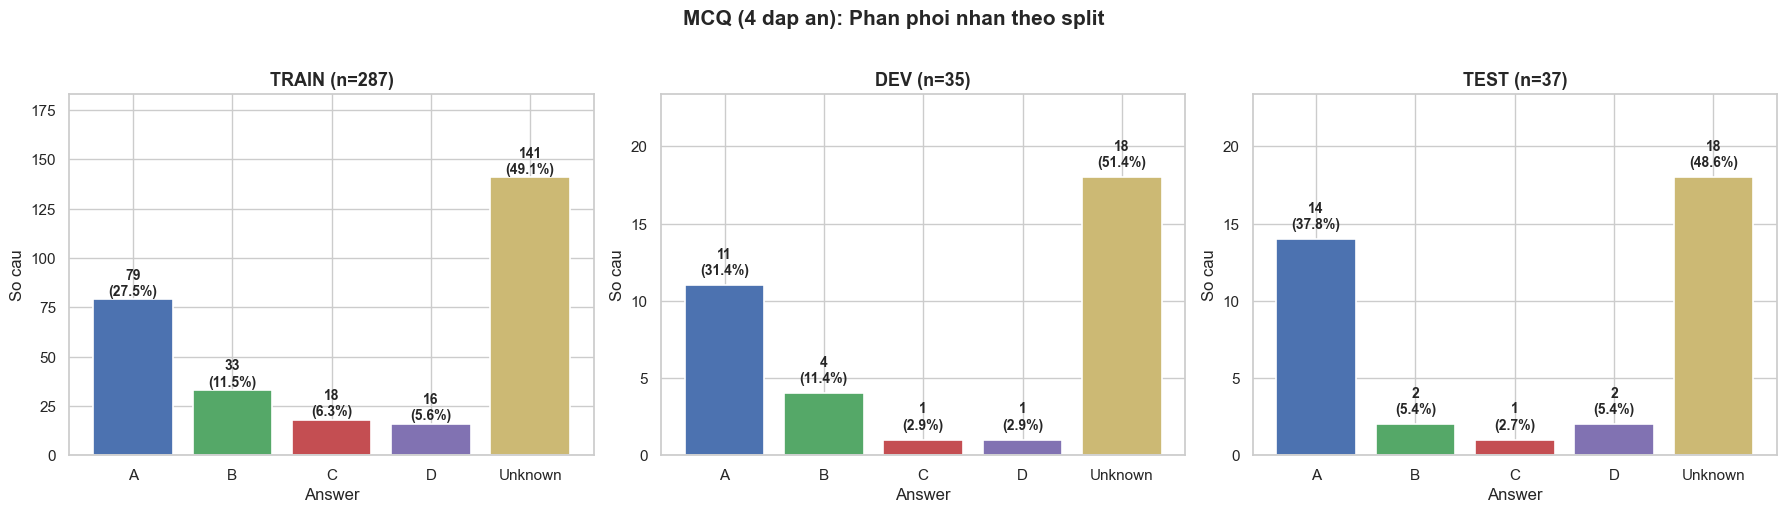

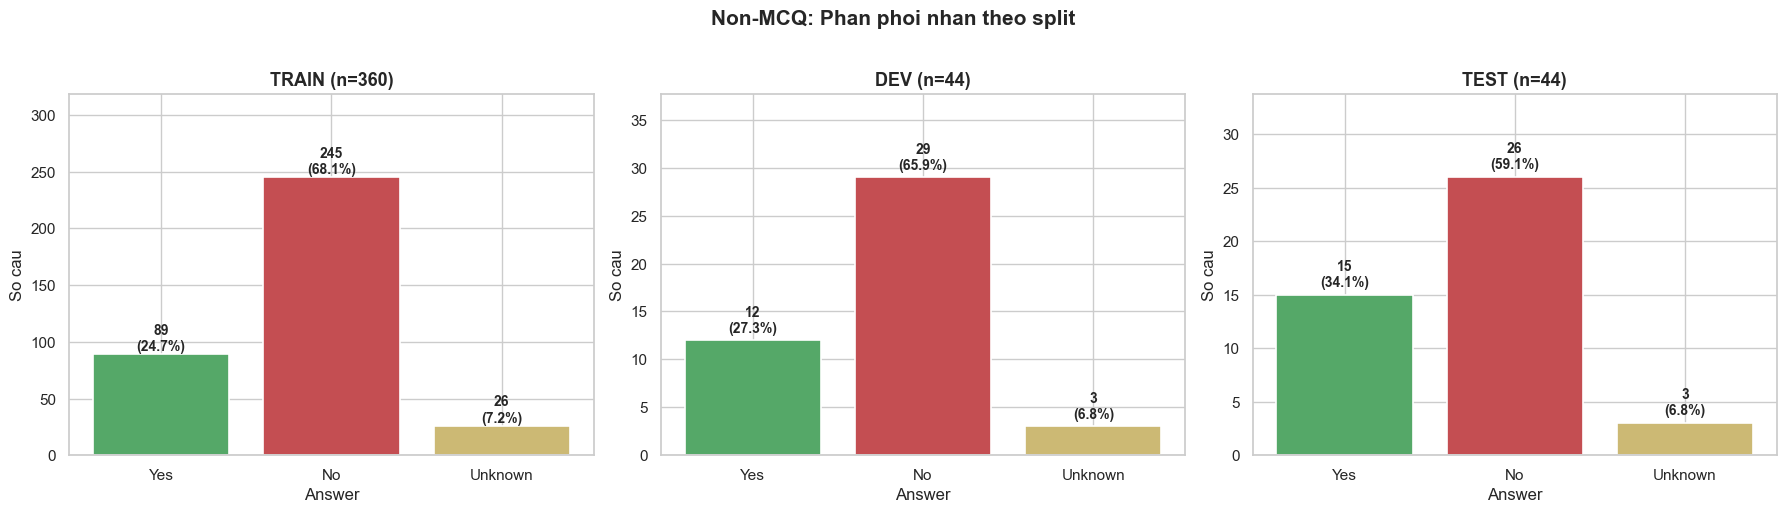

PHAN PHOI NHAN THEO SPLIT (sau xoa Other + stratified)
           |                 MCQ                 |          Non-MCQ         
Split      |     A     B     C     D   Unk   Tot |   Yes    No   Unk   Tot
----------------------------------------------------------------------
train      |    79    33    18    16   141   287 |    89   245    26   360
dev        |    11     4     1     1    18    35 |    12    29     3    44
test       |    14     2     1     2    18    37 |    15    26     3    44

Ti le % theo split:
  train: MCQ Unk=49.1% | Non-MCQ No=68.1% Yes=24.7% Unk=7.2%
  dev  : MCQ Unk=51.4% | Non-MCQ No=65.9% Yes=27.3% Unk=6.8%
  test : MCQ Unk=48.6% | Non-MCQ No=59.1% Yes=34.1% Unk=6.8%


In [35]:
# === 6 bieu do phan phoi nhan train/dev/test ===
import re
from collections import Counter

MCQ_RE = re.compile(r"\nA[\\.)\\)]")
SFT_PROCESSED = PROJECT_ROOT / "data" / "processed"

# Load lai train/dev/test vua export
splits = {}
for name in ["train", "dev", "test"]:
    splits[name] = pd.read_csv(SFT_PROCESSED / f"{name}.csv")

# Classify MCQ vs Non-MCQ per split
def classify_split(df):
    mcq_answers, non_mcq_answers = [], []
    for _, row in df.iterrows():
        q = str(row["question"])
        a = str(row["answer"]).strip()
        if MCQ_RE.search(q):
            mcq_answers.append(a)
        else:
            non_mcq_answers.append(a)
    return Counter(mcq_answers), Counter(non_mcq_answers)

split_stats = {name: classify_split(df) for name, df in splits.items()}

# --- Figure 1: MCQ (3 subplots: train / dev / test) ---
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))
fig1.suptitle("MCQ (4 dap an): Phan phoi nhan theo split", fontsize=15, fontweight="bold", y=1.02)
mcq_labels = ["A", "B", "C", "D", "Unknown"]
colors_mcq = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]

for ax, (name, (mcq_c, _)) in zip(axes1, split_stats.items()):
    vals = [mcq_c.get(l, 0) for l in mcq_labels]
    total = sum(vals)
    bars = ax.bar(mcq_labels, vals, color=colors_mcq, edgecolor="white", linewidth=1.2)
    for bar, val in zip(bars, vals):
        pct = val / total * 100 if total else 0
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{val}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title(f"{name.upper()} (n={total})", fontsize=13, fontweight="bold")
    ax.set_xlabel("Answer")
    ax.set_ylabel("So cau")
    if total > 0:
        ax.set_ylim(0, max(vals) * 1.3)

plt.tight_layout()
fig1.savefig(FIG_DIR / "label_dist_mcq_splits.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Figure 2: Non-MCQ (3 subplots: train / dev / test) ---
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle("Non-MCQ: Phan phoi nhan theo split", fontsize=15, fontweight="bold", y=1.02)
non_mcq_labels = ["Yes", "No", "Unknown"]
colors_non = ["#55A868", "#C44E52", "#CCB974"]

for ax, (name, (_, non_c)) in zip(axes2, split_stats.items()):
    vals = [non_c.get(l, 0) for l in non_mcq_labels]
    total = sum(vals)
    bars = ax.bar(non_mcq_labels, vals, color=colors_non, edgecolor="white", linewidth=1.2)
    for bar, val in zip(bars, vals):
        pct = val / total * 100 if total else 0
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{val}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title(f"{name.upper()} (n={total})", fontsize=13, fontweight="bold")
    ax.set_xlabel("Answer")
    ax.set_ylabel("So cau")
    if total > 0:
        ax.set_ylim(0, max(vals) * 1.3)

plt.tight_layout()
fig2.savefig(FIG_DIR / "label_dist_non_mcq_splits.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Summary table ---
print("=" * 70)
print("PHAN PHOI NHAN THEO SPLIT (sau xoa Other + stratified)")
print("=" * 70)
header = f"{'':10s} | {'MCQ':^35s} | {'Non-MCQ':^25s}"
print(header)
print(f"{'Split':10s} | {'A':>5s} {'B':>5s} {'C':>5s} {'D':>5s} {'Unk':>5s} {'Tot':>5s} | {'Yes':>5s} {'No':>5s} {'Unk':>5s} {'Tot':>5s}")
print("-" * 70)
for name in ["train", "dev", "test"]:
    mc, nc = split_stats[name]
    mt = sum(mc.values())
    nt = sum(nc.values())
    print(f"{name:10s} | {mc.get('A',0):5d} {mc.get('B',0):5d} {mc.get('C',0):5d} {mc.get('D',0):5d} {mc.get('Unknown',0):5d} {mt:5d} | {nc.get('Yes',0):5d} {nc.get('No',0):5d} {nc.get('Unknown',0):5d} {nt:5d}")

print()
print("Ti le % theo split:")
for name in ["train", "dev", "test"]:
    mc, nc = split_stats[name]
    mt = sum(mc.values()) or 1
    nt = sum(nc.values()) or 1
    unk_mcq = mc.get("Unknown", 0) / mt * 100
    print(f"  {name:5s}: MCQ Unk={unk_mcq:.1f}% | Non-MCQ No={nc.get('No',0)/nt*100:.1f}% Yes={nc.get('Yes',0)/nt*100:.1f}% Unk={nc.get('Unknown',0)/nt*100:.1f}%")


## 9. Tóm tắt định lượng (điền tự động)


In [36]:
summary = f"""
=== TÓM TẮT EDA — Logic_Based_Educational_Queries ===

• Câu / mẫu: mean={qpc.mean():.2f}, P50={qpc.median():.0f}, max={qpc.max()} ({pct_1:.1f}% mẫu 1 câu, {pct_2:.1f}% 2 câu)
• Tổng câu: {len(df_q)} (BTC {BTC['n_questions']})
• Premise NL / mẫu: mean={df_rec['n_premises_nl'].mean():.2f} (BTC ~{BTC['nl_per_record']})
• Premise dùng / câu: P50={df_q['n_premises_used'].median():.0f}, P90={df_q['n_premises_used'].quantile(0.9):.0f}
• MCQ: premise dùng P50={df_q.loc[df_q['is_mcq'], 'n_premises_used'].median():.0f}
• Y/N:  premise dùng P50={df_q.loc[df_q['is_yn'], 'n_premises_used'].median():.0f}
• % Unknown: {100*(df_q['answer_norm']=='Unknown').mean():.1f}%
• % explanation cite ⊆ idx: {df_q['cite_subset'].mean():.1%}
• % mẫu có FOL: {df_rec['has_fol'].mean():.1%}
• Loại câu (chồng): MCQ={df_q['is_mcq'].sum()}, Y/N={df_q['is_yn'].sum()}, Open={df_q['is_open'].sum()}
"""
print(summary)

with open(OUT_DIR / "eda_summary.txt", "w", encoding="utf-8") as f:
    f.write(summary)

export_cols = [
    "record_id", "q_idx", "n_premises_nl", "n_premises_used", "premise_use_ratio",
    "question", "answer", "answer_norm", "is_mcq", "is_yn", "is_open",
    "exp_words", "n_cited_in_exp", "cite_subset", "has_numeric",
]
df_q[export_cols].to_csv(OUT_DIR / "logic_flat.csv", index=False)
print(f"Đã lưu: {OUT_DIR / 'logic_flat.csv'}, {OUT_DIR / 'eda_summary.txt'}")
print(f"Figures: {FIG_DIR}")



=== TÓM TẮT EDA — Logic_Based_Educational_Queries ===

• Câu / mẫu: mean=1.97, P50=2, max=2 (3.4% mẫu 1 câu, 96.6% 2 câu)
• Tổng câu: 808 (BTC 808)
• Premise NL / mẫu: mean=10.80 (BTC ~10.8)
• Premise dùng / câu: P50=2, P90=4
• MCQ: premise dùng P50=3
• Y/N:  premise dùng P50=2
• % Unknown: 25.9%
• % explanation cite ⊆ idx: 88.7%
• % mẫu có FOL: 100.0%
• Loại câu (chồng): MCQ=359, Y/N=216, Open=233

Đã lưu: E:\exact_2026\Exact_2026_Laplace-s_Red_Devils\Logic_Based_Educational_Queries_Project\data\interim\eda\logic_flat.csv, E:\exact_2026\Exact_2026_Laplace-s_Red_Devils\Logic_Based_Educational_Queries_Project\data\interim\eda\eda_summary.txt
Figures: E:\exact_2026\Exact_2026_Laplace-s_Red_Devils\Logic_Based_Educational_Queries_Project\reports\figures


## 10. Xuất CSV → `data/processed/`

**Quan trọng:** phải chạy các ô chuẩn hóa trước (tạo `records_norm`). Cell dưới gọi `export_from_records(records_norm, …)` — ghi **chung** `train/dev/test` + `split_*.json` vào `data/processed/` (logic MCQ + FOL dùng cùng thư mục).  
Nếu gọi `export_from_json_path(DATA_PATH, …)` thì chỉ đọc JSON gốc trên đĩa — không dùng `records_norm` trong RAM.

`make data` ghi cùng đích `data/processed/`.

In [37]:
# === Export da duoc thay the boi cell 8c (stratified split) ===
# Cell nay giu lai de tham khao, KHONG can chay lai.
# export_from_records(records_norm, SFT_PROCESSED)
print("Skip — da export stratified o cell 8c")


Skip — da export stratified o cell 8c
